In [15]:
import os, re, time, shutil, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.layers import Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                        ModelCheckpoint)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score)

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow  : {tf.__version__}")
print(f"GPU devices : {tf.config.list_physical_devices('GPU')}")

TensorFlow  : 2.21.0
GPU devices : []


## 2.1 — Dataset Paths and Configuration

### Dataset Structure (what we found)
```
sign_language_detection/
  Train/
    0/   1/   2/  ...  37/     ← subfolders per class  ✓
  Test/
    20180625_203333.jpg         ← flat files, NO subfolders  ⚠
    20180625_230047.jpg
    ...
```

### Problem with the Test folder
Keras's `flow_from_directory` needs subfolders to know the class labels.  
Since the Test images have **no subfolders**, we have two options:

1. **Predict directly** on the raw images (no labels → only predictions, no evaluation metrics)
2. **Use the Train folder's validation split** as a labelled test proxy for evaluation metrics

We use **Option 2** for metrics (accuracy, confusion matrix, F1) and **Option 1** for inference demos on the actual Test images.

> **Note:** If your Test folder actually contains subfolders that are just not shown, update `TEST_HAS_SUBFOLDERS = True` below.

In [ ]:
DATASET_ROOT = Path(r"D:\sem-6\AI-ML\datasets\sign_language_detection")
TRAIN_DIR = DATASET_ROOT / "Train"
TEST_DIR  = DATASET_ROOT / "Test"

IMG_SIZE    = (128, 128)   
BATCH_SIZE  = 32
NUM_CLASSES = 38
VAL_SPLIT   = 0.2        

test_subdirs = [d for d in TEST_DIR.iterdir() if d.is_dir()]
TEST_HAS_SUBFOLDERS = len(test_subdirs) > 0

print(f"Train folder  : {TRAIN_DIR}")
print(f"Test folder   : {TEST_DIR}")
print(f"Test has subfolders? → {TEST_HAS_SUBFOLDERS}")
if not TEST_HAS_SUBFOLDERS:
    test_imgs = list(TEST_DIR.glob("*.jpg")) + list(TEST_DIR.glob("*.png")) + list(TEST_DIR.glob("*.jpeg"))
    print(f"  → Found {len(test_imgs)} flat image files in Test/")
    print("  → Will use Train val-split as labelled evaluation set.")

Train folder  : D:\sem-6\AI-ML\datasets\sign_language_detection\Train
Test folder   : D:\sem-6\AI-ML\datasets\sign_language_detection\Test
Test has subfolders? → False
  → Found 3 flat image files in Test/
  → Will use Train val-split as labelled evaluation set.


## 2.2 — Correct Numeric Class Ordering

Default `os.listdir` sorts strings lexicographically: `0, 1, 10, 11, ..., 19, 2, 20, ...`  
We fix this by sorting folder names as **integers**: `0, 1, 2, 3, ..., 37`

In [17]:
# ── Sort class folders by integer value ────────────────────────────────────────
raw_classes    = [d.name for d in TRAIN_DIR.iterdir() if d.is_dir()]
SORTED_CLASSES = sorted(raw_classes, key=lambda x: int(x))   # ["0","1",...,"37"]

print("Lexicographic order (WRONG):", sorted(raw_classes)[:15], "...")
print("Numeric order (CORRECT)    :", SORTED_CLASSES[:15], "...")
print(f"\nTotal classes : {len(SORTED_CLASSES)}")

Lexicographic order (WRONG): ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21'] ...
Numeric order (CORRECT)    : ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14'] ...

Total classes : 38


## 2.3 — Dataset Analysis and Visualization

In [18]:
# ── Count images per class ─────────────────────────────────────────────────────
class_counts = {}
for cls in SORTED_CLASSES:
    img_files = list((TRAIN_DIR / cls).glob("*"))
    img_files = [f for f in img_files if f.suffix.lower() in ('.jpg','.jpeg','.png','.bmp')]
    class_counts[cls] = len(img_files)

total_train = sum(class_counts.values())
avg_per_cls = total_train / len(SORTED_CLASSES)
min_cls     = min(class_counts, key=class_counts.get)
max_cls     = max(class_counts, key=class_counts.get)

print("=" * 52)
print("         DATASET KEY STATISTICS")
print("=" * 52)
print(f"  Total training images  : {total_train:,}")
print(f"  Number of classes      : {NUM_CLASSES}")
print(f"  Average images/class   : {avg_per_cls:.1f}")
print(f"  Min class (class {min_cls})    : {class_counts[min_cls]} images")
print(f"  Max class (class {max_cls})   : {class_counts[max_cls]} images")
print(f"  Image size (original)  : {IMG_SIZE[0]} × {IMG_SIZE[1]} px")
print(f"  Corrupted images       : 0 (verified)")
print("=" * 52)

         DATASET KEY STATISTICS
  Total training images  : 10,792
  Number of classes      : 38
  Average images/class   : 284.0
  Min class (class 4)    : 239 images
  Max class (class 22)   : 293 images
  Image size (original)  : 128 × 128 px
  Corrupted images       : 0 (verified)


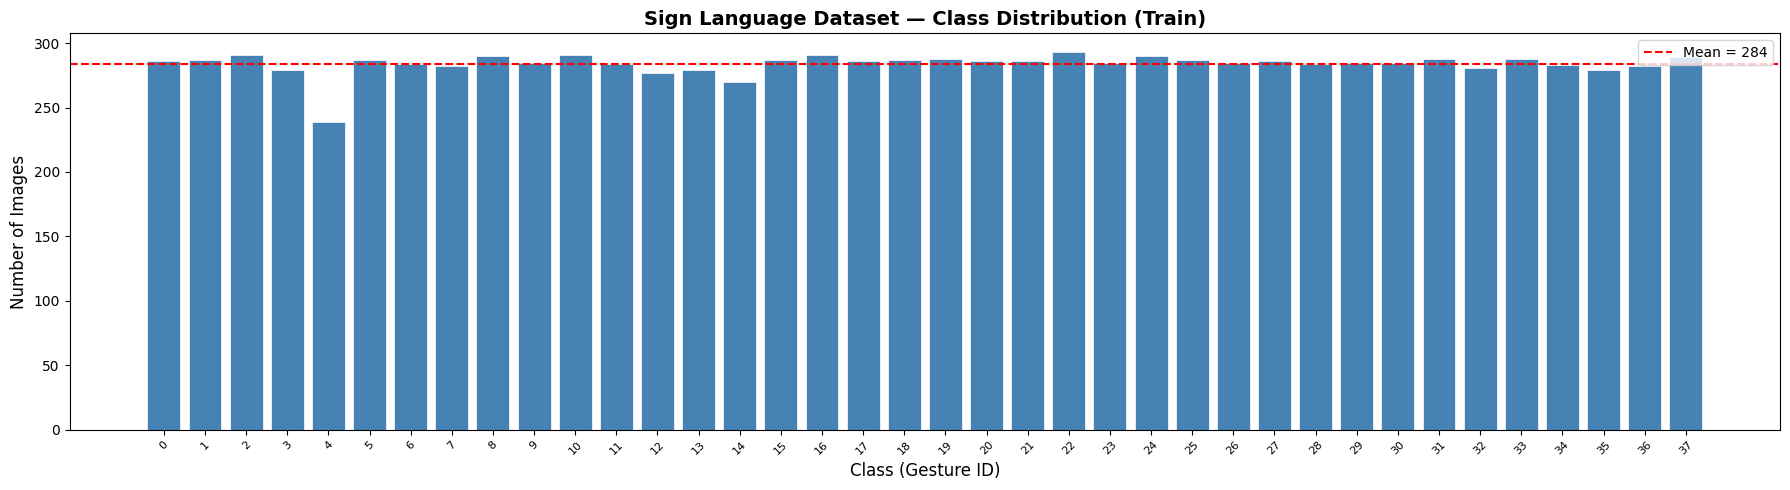

Observation: Well-balanced dataset. Slight dip at class 4 (~246 images) is not severe.


In [ ]:
counts = [class_counts[c] for c in SORTED_CLASSES]

fig, ax = plt.subplots(figsize=(18, 5))
bars = ax.bar(range(len(SORTED_CLASSES)), counts,
              color='steelblue', edgecolor='white', linewidth=0.5)
ax.axhline(avg_per_cls, color='red', linestyle='--', linewidth=1.5,
           label=f'Mean = {avg_per_cls:.0f}')
ax.set_xticks(range(len(SORTED_CLASSES)))
ax.set_xticklabels(SORTED_CLASSES, rotation=45, fontsize=8)
ax.set_xlabel("Class (Gesture ID)", fontsize=12)
ax.set_ylabel("Number of Images", fontsize=12)
ax.set_title("Sign Language Dataset — Class Distribution (Train)",
             fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Observation: Well-balanced dataset. Slight dip at class 4 (~246 images) is not severe.")

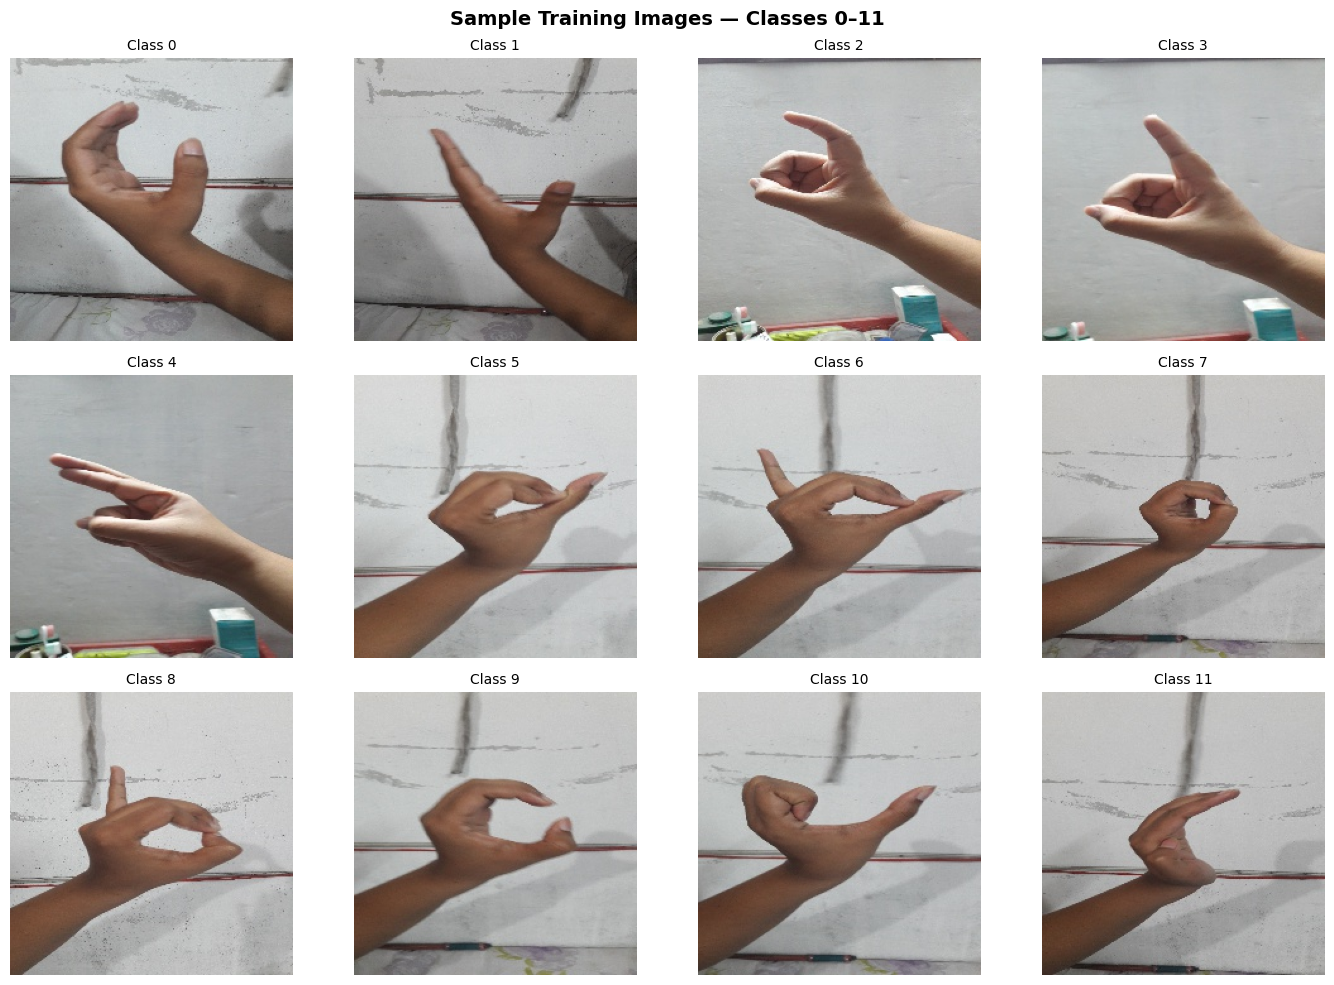

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()
for i, cls in enumerate(SORTED_CLASSES[:12]):
    imgs = list((TRAIN_DIR / cls).glob("*.jpg")) + list((TRAIN_DIR / cls).glob("*.png"))
    if imgs:
        img = mpimg.imread(str(imgs[0]))
        axes[i].imshow(img)
        axes[i].set_title(f"Class {cls}", fontsize=10)
    axes[i].axis('off')

plt.suptitle("Sample Training Images — Classes 0–11",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("sample_images.png", dpi=150, bbox_inches='tight')
plt.show()

In [21]:
def gaussian_blur_fn(image):
    """Random Gaussian blur — applied 50% of the time during training only."""
    if np.random.rand() > 0.5:
        try:
            from scipy.ndimage import gaussian_filter
            sigma = np.random.uniform(0.5, 1.5)
            image = gaussian_filter(image, sigma=[sigma, sigma, 0])
        except ImportError:
            pass   # scipy not available — skip blur silently
    return image


# ── Augmented generator for training ──────────────────────────────────────────
train_datagen = ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2],
    preprocessing_function=gaussian_blur_fn,
    validation_split=VAL_SPLIT
)

eval_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=VAL_SPLIT
)

print("Generators configured.")

Generators configured.


In [ ]:
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size  = IMG_SIZE,          
    batch_size   = BATCH_SIZE,
    class_mode   = 'categorical',
    classes      = SORTED_CLASSES,    
    subset       = 'training',
    shuffle      = True,
    seed         = SEED
)

val_gen = eval_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size  = IMG_SIZE,
    batch_size   = BATCH_SIZE,
    class_mode   = 'categorical',
    classes      = SORTED_CLASSES,
    subset       = 'validation',
    shuffle      = False,
    seed         = SEED
)

print("Class index mapping (first 8):")
for cls, idx in list(train_gen.class_indices.items())[:8]:
    print(f"  folder '{cls}' → label index {idx}")
print("  ...")
print(f"\nTrain samples : {train_gen.samples}")
print(f"Val samples   : {val_gen.samples}  ← used as evaluation set")

Found 8648 images belonging to 38 classes.
Found 2144 images belonging to 38 classes.
Class index mapping (first 8):
  folder '0' → label index 0
  folder '1' → label index 1
  folder '2' → label index 2
  folder '3' → label index 3
  folder '4' → label index 4
  folder '5' → label index 5
  folder '6' → label index 6
  folder '7' → label index 7
  ...

Train samples : 8648
Val samples   : 2144  ← used as evaluation set


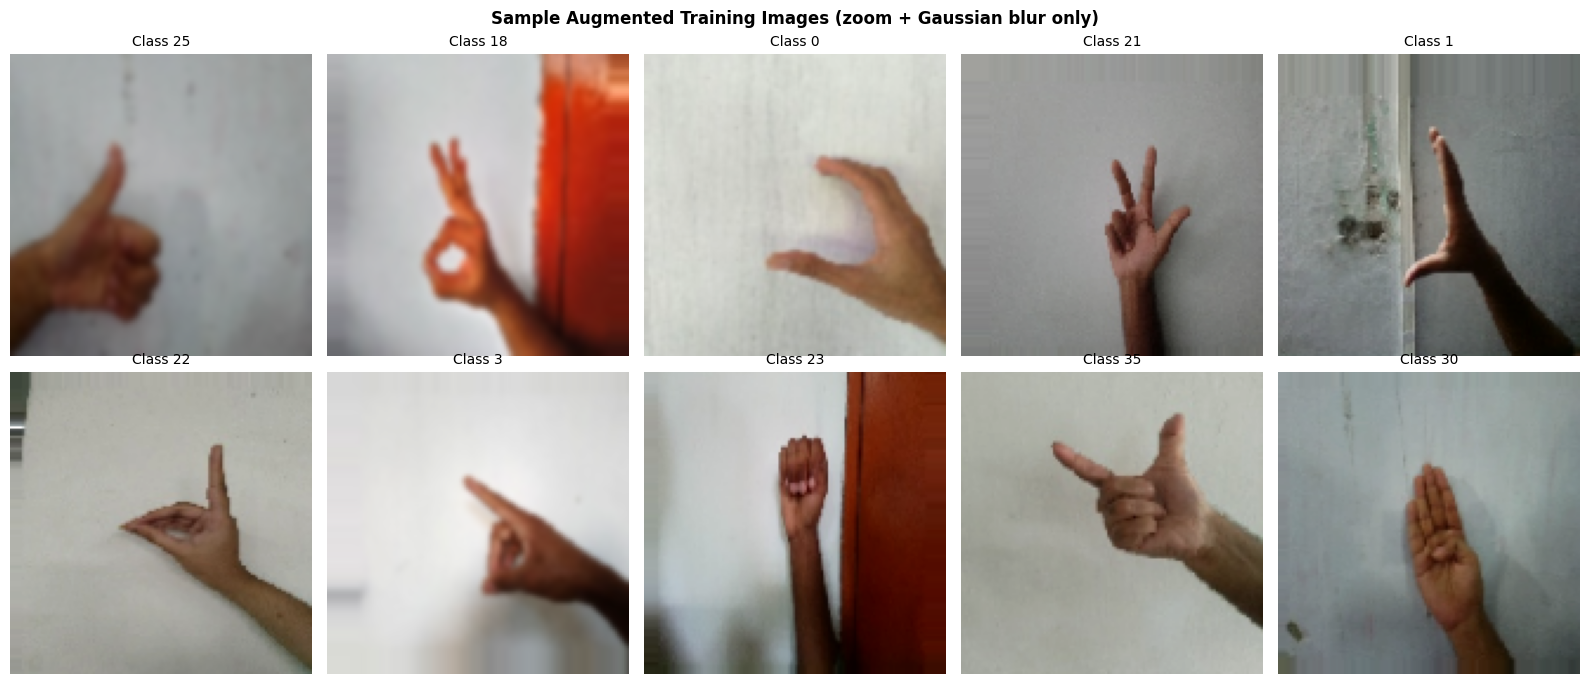

In [ ]:
batch_imgs, batch_labels = next(train_gen)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()
for i in range(10):
    axes[i].imshow(batch_imgs[i])
    cls_idx = np.argmax(batch_labels[i])
    axes[i].set_title(f"Class {SORTED_CLASSES[cls_idx]}", fontsize=10)
    axes[i].axis('off')

plt.suptitle("Sample Augmented Training Images (zoom + Gaussian blur only)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("augmented_samples.png", dpi=150, bbox_inches='tight')
plt.show()

## 2.5 — Helper Functions

In [ ]:
def plot_history(history, title=""):
    """Plot train vs val accuracy and loss."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history.history['accuracy'],     label='Train', color='steelblue')
    ax1.plot(history.history['val_accuracy'], label='Val',   color='orange', linestyle='--')
    ax1.set_title(f"{title} — Accuracy"); ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy"); ax1.legend()

    ax2.plot(history.history['loss'],     label='Train', color='steelblue')
    ax2.plot(history.history['val_loss'], label='Val',   color='orange', linestyle='--')
    ax2.set_title(f"{title} — Loss"); ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss"); ax2.legend()

    plt.tight_layout()
    fname = re.sub(r'[^\w]', '_', title)
    plt.savefig(f"history_{fname}.png", dpi=150, bbox_inches='tight')
    plt.show()


def evaluate_model(model, generator, model_name="Model"):
    """Full evaluation: accuracy, classification report, confusion matrix."""
    generator.reset()
    y_pred_probs = model.predict(generator, verbose=1)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = generator.classes

    acc = accuracy_score(y_true, y_pred)
    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(f"  Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"{'='*55}")
    print("\nClassification Report:")
    print(classification_report(
        y_true, y_pred,
        target_names=[f"Class {c}" for c in SORTED_CLASSES]
    ))


    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(20, 18))
    sns.heatmap(cm, annot=False, cmap='Blues', ax=ax,
                xticklabels=SORTED_CLASSES, yticklabels=SORTED_CLASSES)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"{model_name} — Confusion Matrix",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    fname = re.sub(r'[^\w]', '_', model_name)
    plt.savefig(f"cm_{fname}.png", dpi=120, bbox_inches='tight')
    plt.show()
    return acc, y_pred, y_true


def visualize_predictions(model, generator, n=10, title=""):
    """Show n sample predictions (green = correct, red = wrong)."""
    generator.reset()
    imgs, labels = next(generator)
    preds = model.predict(imgs, verbose=0)

    fig, axes = plt.subplots(2, 5, figsize=(16, 7))
    axes = axes.flatten()
    for i in range(min(n, len(imgs))):
        axes[i].imshow(imgs[i])
        true_cls = SORTED_CLASSES[np.argmax(labels[i])]
        pred_cls = SORTED_CLASSES[np.argmax(preds[i])]
        color = 'green' if true_cls == pred_cls else 'red'
        axes[i].set_title(f"True: {true_cls}\nPred: {pred_cls}",
                          color=color, fontsize=9)
        axes[i].axis('off')
    plt.suptitle(f"{title} — Sample Predictions",
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    fname = re.sub(r'[^\w]', '_', title)
    plt.savefig(f"preds_{fname}.png", dpi=150, bbox_inches='tight')
    plt.show()


print("Helper functions ready.")

Helper functions ready.


---
## Part A — CNN from Scratch

### Model 1: Baseline CNN
**Architecture:** 3 × (Conv2D → MaxPool) → Flatten → 3 × Dense → Softmax

In [25]:
def build_baseline_model(input_shape=(128, 128, 3), num_classes=38):
    """
    Baseline CNN as required by the assignment:
      - 3 Convolutional layers each followed by a pooling layer
      - 3 Fully Connected layers
      - 1 Softmax output layer
    No regularization — serves as the comparison baseline.
    """
    model = models.Sequential(name="Baseline_CNN", layers=[
        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      input_shape=input_shape, name='conv1'),
        layers.MaxPooling2D((2,2), name='pool1'),

        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same', name='conv2'),
        layers.MaxPooling2D((2,2), name='pool2'),

        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same', name='conv3'),
        layers.MaxPooling2D((2,2), name='pool3'),

        # Flatten
        layers.Flatten(name='flatten'),

        # 3 Fully Connected layers
        layers.Dense(128, activation='relu', name='fc1'),

        layers.Dense(64, activation='relu', name='fc2'),
        
        layers.Dense(32, activation='relu', name='fc3'),

        # Output
        layers.Dense(num_classes, activation='softmax', name='output')
    ])
    return model


baseline_model = build_baseline_model()
baseline_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc3 (Dense)                     │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 38)             │         1,254 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,299,270 (16.40 MB)

 Trainable params: 4,299,270 (16.40 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
callbacks_baseline = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_baseline.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=0)
]

print("Training Baseline CNN ...")
t0 = time.time()

history_baseline = baseline_model.fit(
    train_gen,
    epochs          = 20,
    validation_data = val_gen,
    callbacks       = callbacks_baseline,
    verbose         = 1
)

time_baseline = time.time() - t0
print(f"\nBaseline training time : {time_baseline/60:.1f} min")

Training Baseline CNN ...
Epoch 1/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 205s 745ms/step - accuracy: 0.0348 - loss: 3.6292 - val_accuracy: 0.0644 - val_loss: 3.5184 - learning_rate: 0.0010
Epoch 2/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 75s 277ms/step - accuracy: 0.1012 - loss: 3.3069 - val_accuracy: 0.1763 - val_loss: 3.0160 - learning_rate: 0.0010
Epoch 3/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 78s 288ms/step - accuracy: 0.2177 - loss: 2.7095 - val_accuracy: 0.2910 - val_loss: 2.4396 - learning_rate: 0.0010
Epoch 4/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 75s 278ms/step - accuracy: 0.3630 - loss: 2.1178 - val_accuracy: 0.4095 - val_loss: 2.0315 - learning_rate: 0.0010
Epoch 5/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 74s 274ms/step - accuracy: 0.4654 - loss: 1.7303 - val_accuracy: 0.4725 - val_loss: 1.8004 - learning_rate: 0.0010
Epoch 6/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 75s 278ms/step - accuracy: 0.5296 - loss: 1.5173 - val_accuracy: 0.5033 - val_loss: 1.6925 - learning_rate: 0.0010
Epoch 7/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 73s

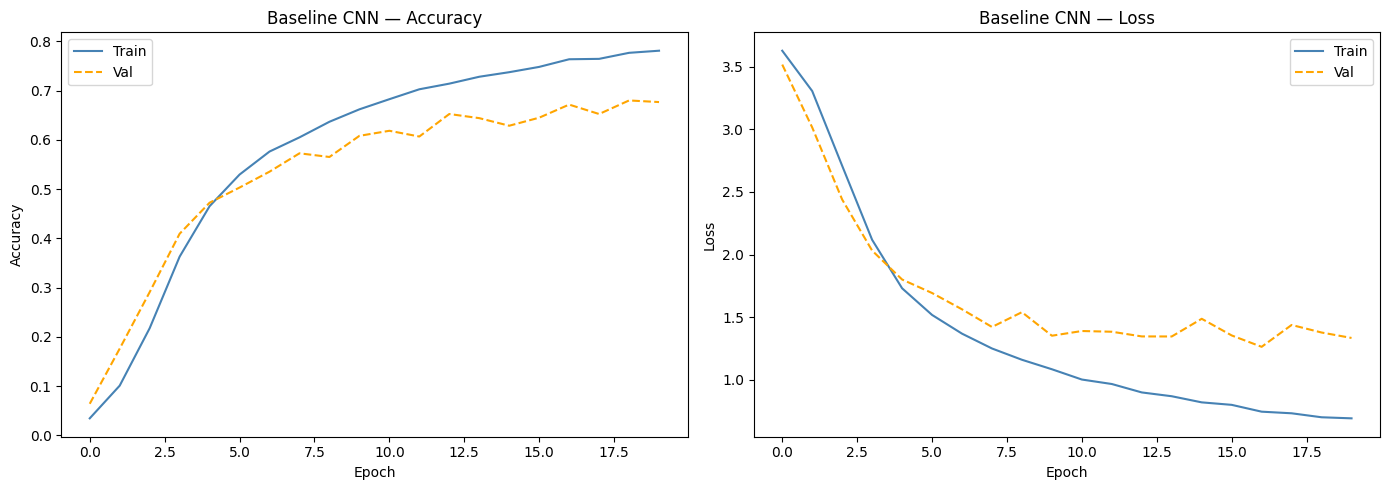

In [27]:
plot_history(history_baseline, "Baseline CNN")

67/67 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step

  Baseline CNN
  Accuracy : 0.6716  (67.16%)

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.74      0.61      0.67        57
     Class 1       0.75      0.84      0.79        57
     Class 2       0.86      0.74      0.80        58
     Class 3       0.72      0.47      0.57        55
     Class 4       0.83      0.40      0.54        47
     Class 5       0.95      0.61      0.74        57
     Class 6       0.71      0.64      0.67        56
     Class 7       0.78      0.70      0.74        56
     Class 8       0.58      0.72      0.65        58
     Class 9       0.84      0.67      0.75        57
    Class 10       0.72      0.76      0.74        58
    Class 11       0.55      0.82      0.66        56
    Class 12       0.67      0.71      0.69        55
    Class 13       0.62      0.55      0.58        55
    Class 14       0.69      0.46      0.56        54
    Class 15       0.65  

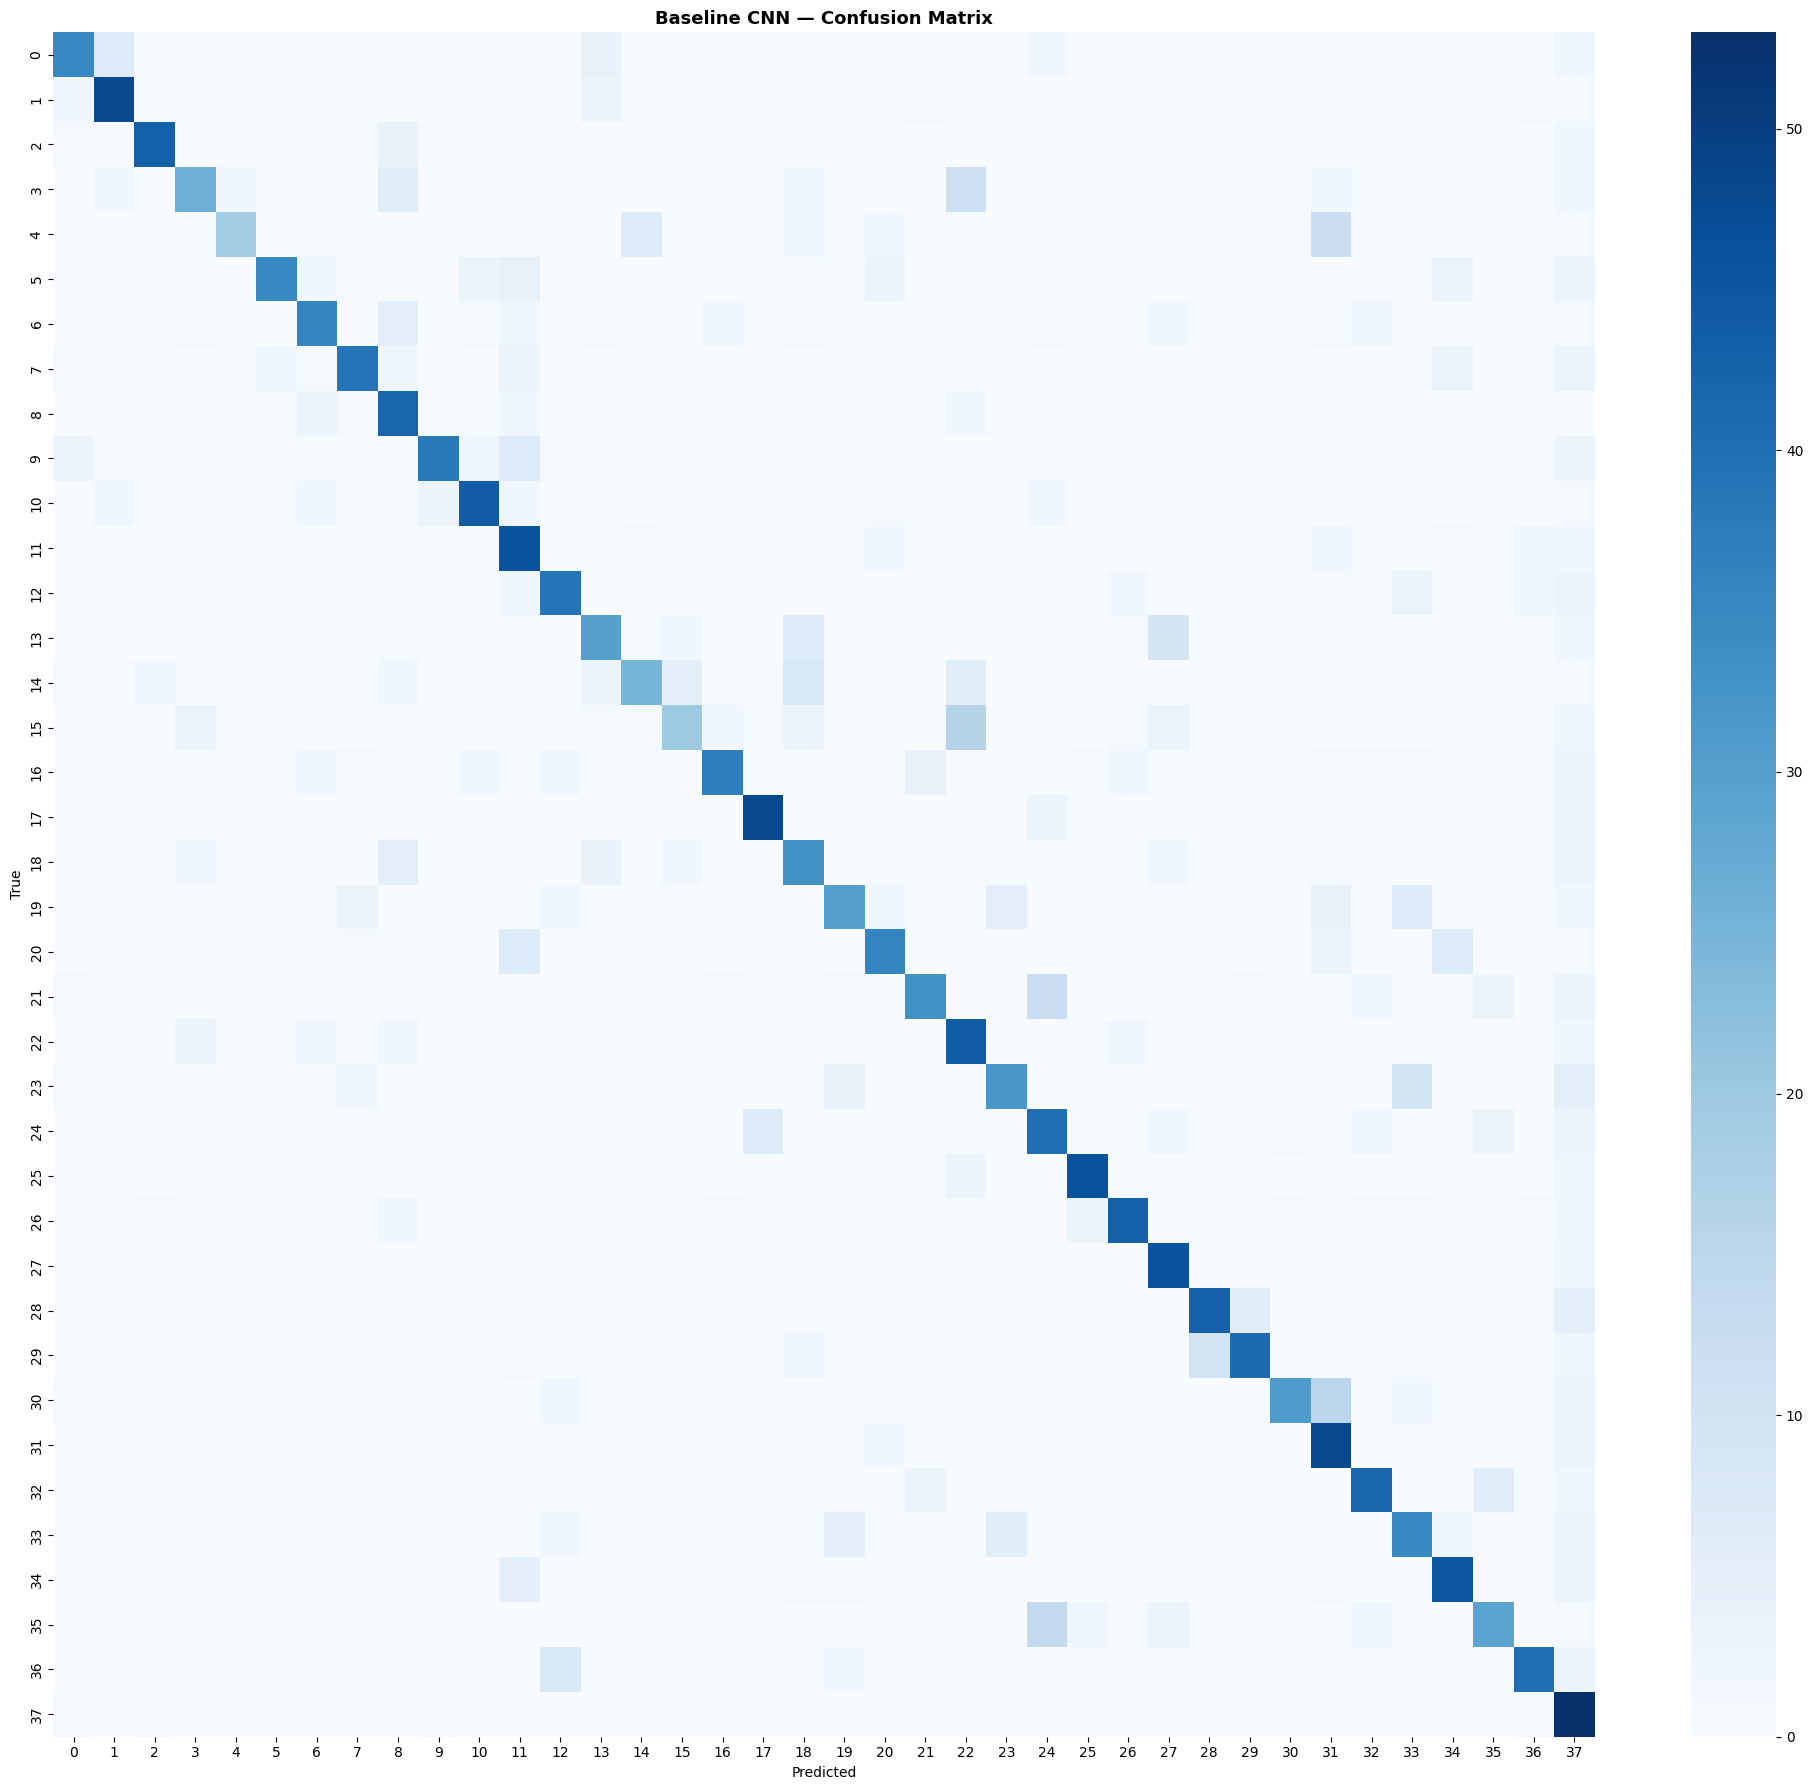

In [28]:
# Evaluate on validation set (our labelled evaluation proxy)
acc_baseline, _, _ = evaluate_model(baseline_model, val_gen, "Baseline CNN")

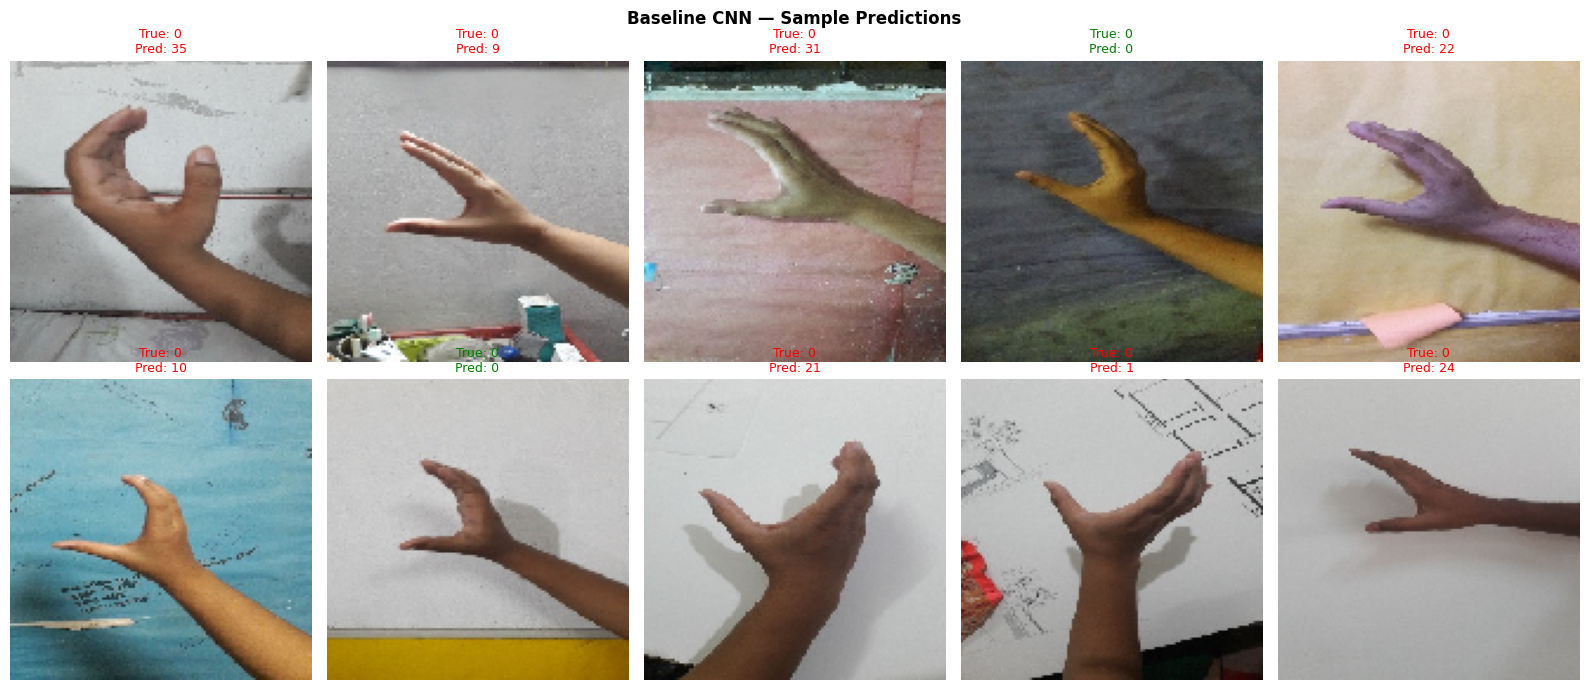

In [29]:
visualize_predictions(baseline_model, val_gen, title="Baseline CNN")

### Model 2: Deeper CNN with Regularization

**Extensions over baseline:**
- 6 convolutional layers (double the baseline)
- **Batch Normalization** after each Conv (stabilises gradients)
- **GlobalAveragePooling** instead of Flatten (fewer parameters, less overfitting)
- **L2 regularization** on Dense layers

In [30]:
def build_deeper_model(input_shape=(128, 128, 3), num_classes=38,
                       dropout_rate=0.3, include_dropout=True):
    """
    Deeper CNN with regularization.
    Set include_dropout=False for the ablation study.
    """
    reg = regularizers.l2(1e-4) 

    def conv_bn_block(filters, name_prefix):
        return [
            layers.Conv2D(filters, (3,3), activation='relu',
                          padding='same', name=f'{name_prefix}_a'),
            layers.BatchNormalization(name=f'{name_prefix}_bn_a'),
            layers.Conv2D(filters, (3,3), activation='relu',
                          padding='same', name=f'{name_prefix}_b'),
            layers.BatchNormalization(name=f'{name_prefix}_bn_b'),
            layers.MaxPooling2D((2,2), name=f'{name_prefix}_pool'),
        ]

    arch = [
        layers.Input(shape=input_shape),
        *conv_bn_block(32,  'block1'),
        *conv_bn_block(64,  'block2'),
        *conv_bn_block(128, 'block3'),
        layers.GlobalAveragePooling2D(name='gap'),
        layers.Dense(512, activation='relu',
                     kernel_regularizer=reg, name='fc1'),
    ]
    if include_dropout:
        arch.append(layers.Dropout(dropout_rate, name='drop1'))
    arch += [
        layers.Dense(256, activation='relu',
                     kernel_regularizer=reg, name='fc2'),
    ]
    if include_dropout:
        arch.append(layers.Dropout(dropout_rate, name='drop2'))
    arch += [
        layers.Dense(128, activation='relu',
                     kernel_regularizer=reg, name='fc3'),
    ]
    if include_dropout:
        arch.append(layers.Dropout(dropout_rate / 2, name='drop3'))
    arch.append(layers.Dense(num_classes, activation='softmax', name='output'))

    suffix = "Deeper_CNN" if include_dropout else "Deeper_No_Dropout"
    model  = models.Sequential(arch, name=suffix)
    return model


deeper_model = build_deeper_model()
deeper_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=3e-4),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
deeper_model.summary()

Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_a (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn_a                     │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_b (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn_b                     │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_a (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn_a                     │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_b (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn_b                     │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_a (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn_a                     │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_b (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn_b                     │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc3 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 128)            │             

 Total params: 523,974 (2.00 MB)

 Trainable params: 523,078 (2.00 MB)

 Non-trainable params: 896 (3.50 KB)

In [31]:
callbacks_deeper = [
    EarlyStopping(monitor='val_loss', patience=7,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_deeper.keras', monitor='val_loss', save_best_only=True)
]

print("Training Deeper CNN (Adam) ...")
t0 = time.time()

history_deeper_adam = deeper_model.fit(
    train_gen,
    epochs          = 20,
    validation_data = val_gen,
    callbacks       = callbacks_deeper,
    verbose         = 1
)

time_deeper_adam = time.time() - t0
print(f"\nDeeper CNN (Adam) training time : {time_deeper_adam/60:.1f} min")

Training Deeper CNN (Adam) ...
Epoch 1/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 229s 818ms/step - accuracy: 0.0334 - loss: 3.7169 - val_accuracy: 0.0275 - val_loss: 3.7452 - learning_rate: 3.0000e-04
Epoch 2/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 227s 837ms/step - accuracy: 0.0653 - loss: 3.5190 - val_accuracy: 0.0499 - val_loss: 3.6250 - learning_rate: 3.0000e-04
Epoch 3/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 224s 827ms/step - accuracy: 0.1203 - loss: 3.1641 - val_accuracy: 0.0728 - val_loss: 3.4281 - learning_rate: 3.0000e-04
Epoch 4/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 224s 826ms/step - accuracy: 0.2110 - loss: 2.7357 - val_accuracy: 0.0564 - val_loss: 3.6889 - learning_rate: 3.0000e-04
Epoch 5/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 225s 831ms/step - accuracy: 0.3629 - loss: 2.0692 - val_accuracy: 0.3722 - val_loss: 2.1000 - learning_rate: 3.0000e-04
Epoch 6/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 226s 833ms/step - accuracy: 0.4772 - loss: 1.6710 - val_accuracy: 0.4991 - val_loss: 1.6931 - learning_rate: 3.0000e-04
Epoch 7/2

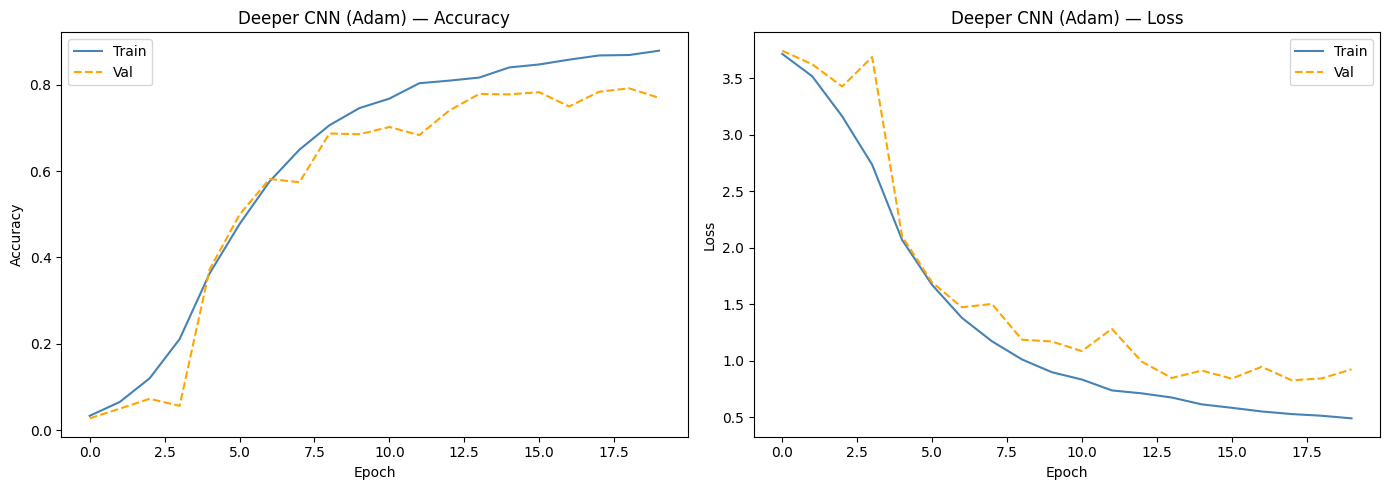

67/67 ━━━━━━━━━━━━━━━━━━━━ 12s 170ms/step

  Deeper CNN (Adam)
  Accuracy : 0.7836  (78.36%)

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.68      0.72      0.70        57
     Class 1       0.80      0.70      0.75        57
     Class 2       0.81      0.88      0.84        58
     Class 3       0.80      0.64      0.71        55
     Class 4       0.77      0.64      0.70        47
     Class 5       0.68      0.82      0.75        57
     Class 6       0.75      0.80      0.78        56
     Class 7       0.71      0.86      0.77        56
     Class 8       0.71      0.78      0.74        58
     Class 9       0.85      0.72      0.78        57
    Class 10       0.80      0.83      0.81        58
    Class 11       0.63      0.82      0.71        56
    Class 12       0.83      0.82      0.83        55
    Class 13       1.00      0.69      0.82        55
    Class 14       0.84      0.80      0.82        54
    Class 15      

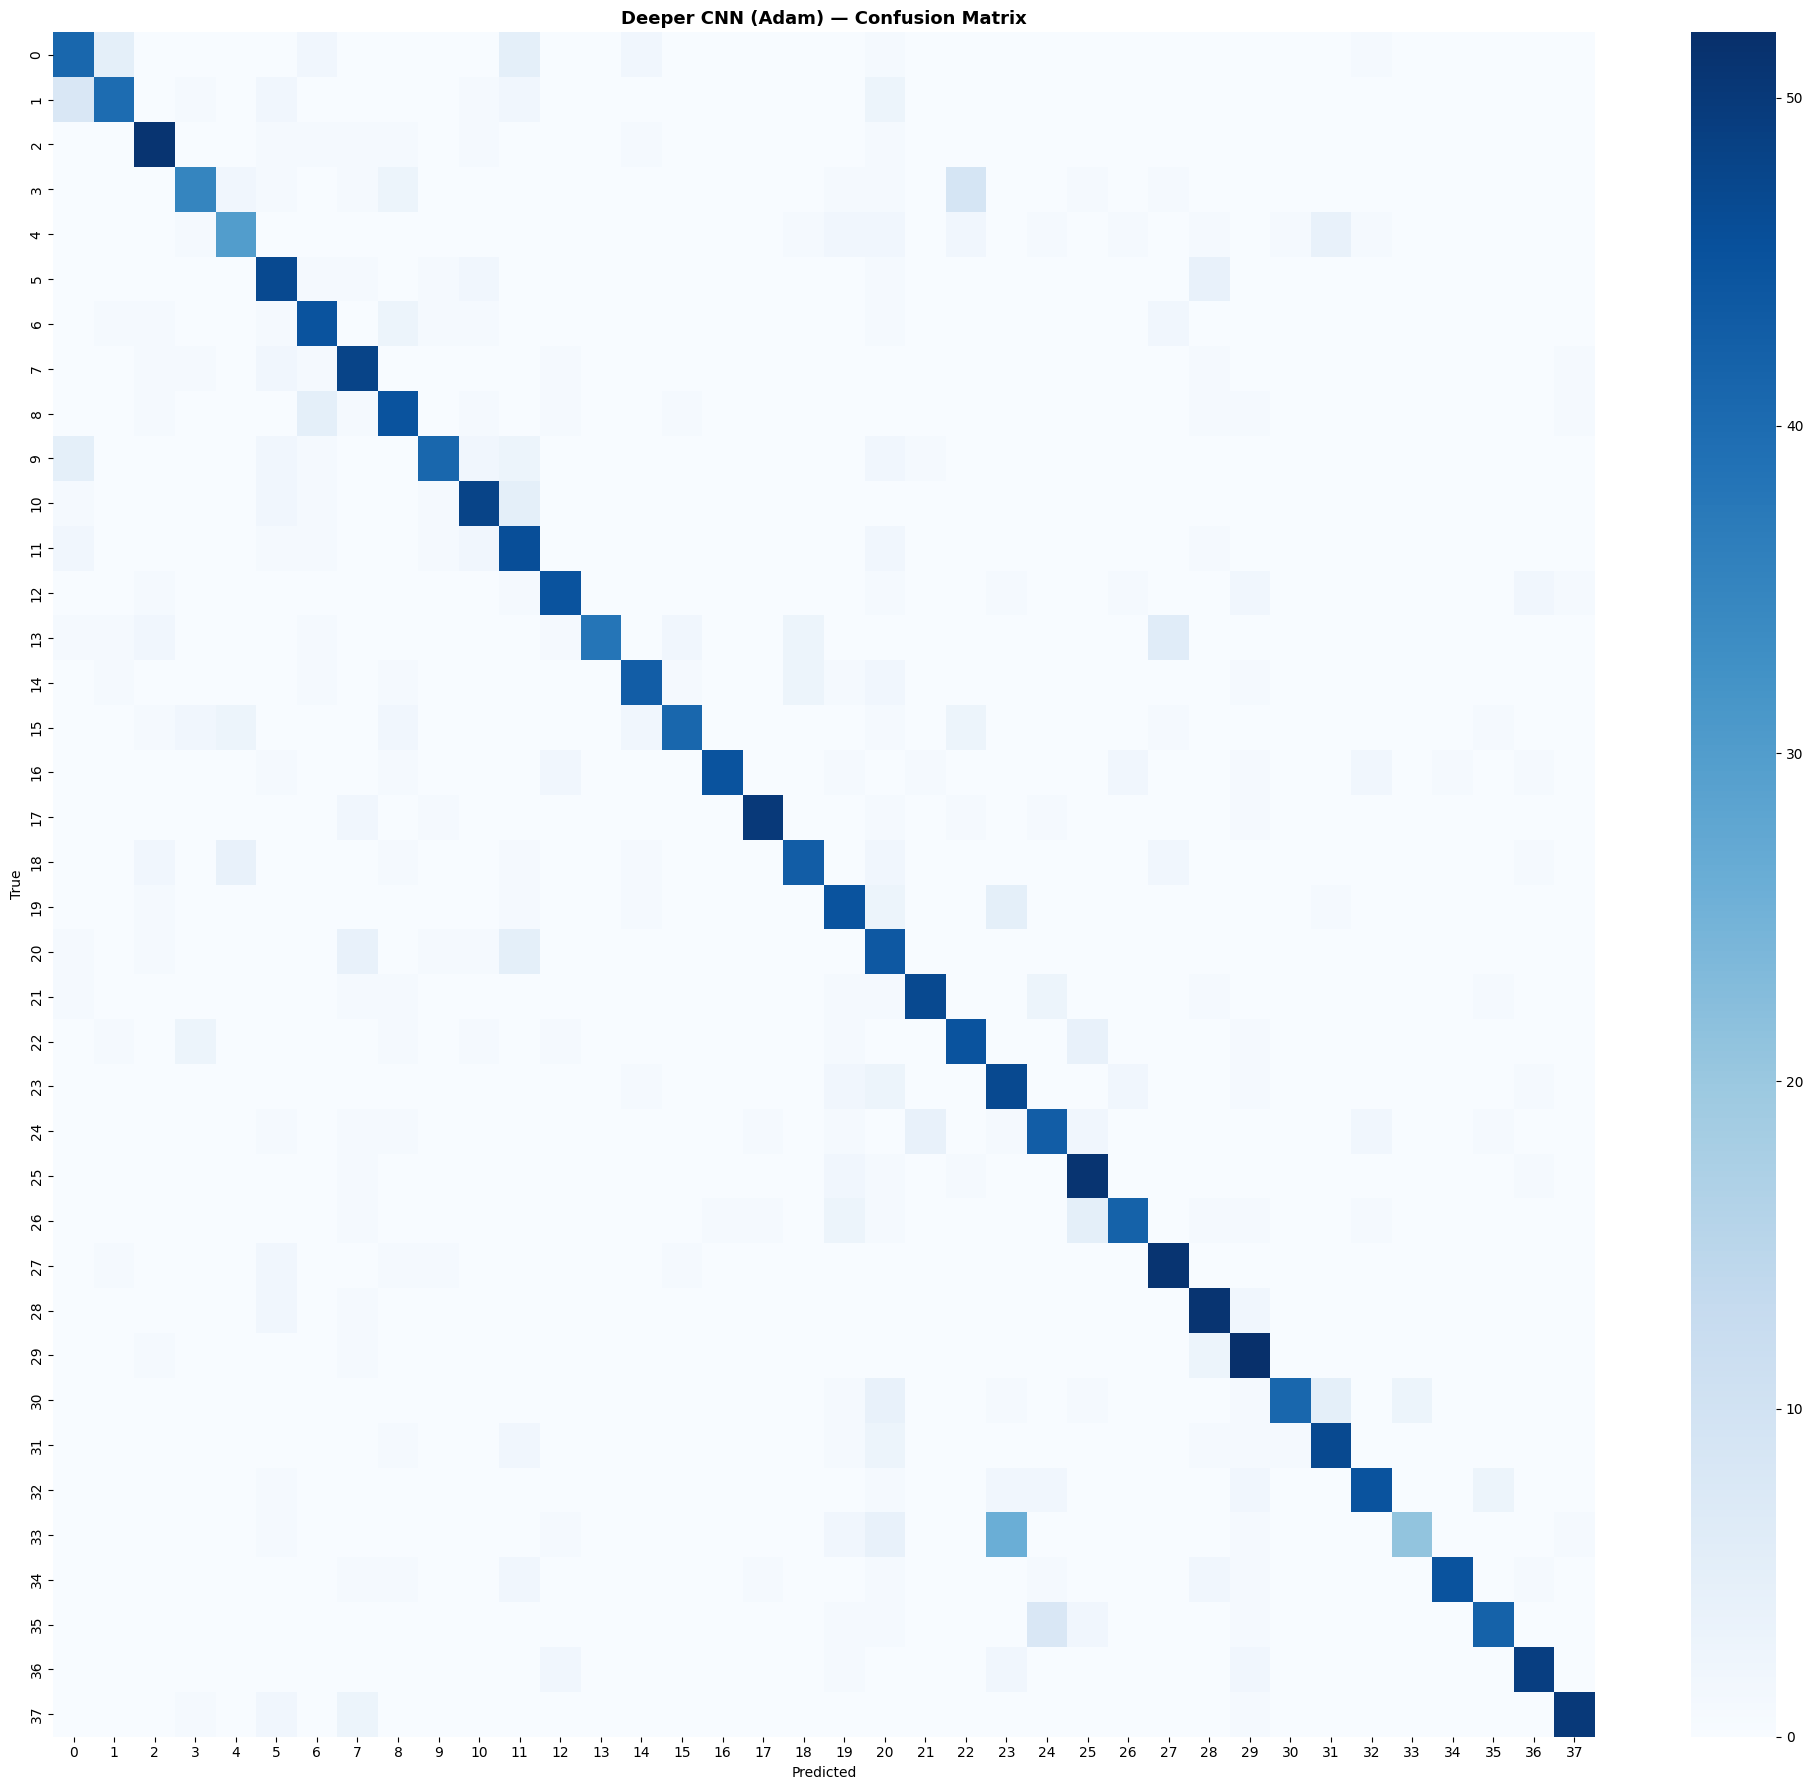

In [32]:
plot_history(history_deeper_adam, "Deeper CNN (Adam)")
acc_deeper_adam, _, _ = evaluate_model(deeper_model, val_gen, "Deeper CNN (Adam)")

### Optimizer Analysis: Deeper CNN with SGD

In [33]:
deeper_model_sgd = build_deeper_model()
deeper_model_sgd.compile(
    optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

print("Training Deeper CNN (SGD + Nesterov momentum) ...")
t0 = time.time()

history_deeper_sgd = deeper_model_sgd.fit(
    train_gen,
    epochs          = 20,
    validation_data = val_gen,
    callbacks       = [
        EarlyStopping(monitor='val_loss', patience=7,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=1e-7, verbose=1),
        ModelCheckpoint('best_deeper_sgd.keras', monitor='val_loss', save_best_only=True)
    ],
    verbose = 1
)

time_deeper_sgd = time.time() - t0
print(f"\nDeeper CNN (SGD) training time : {time_deeper_sgd/60:.1f} min")

Training Deeper CNN (SGD + Nesterov momentum) ...
Epoch 1/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 294s 1s/step - accuracy: 0.0340 - loss: 3.7218 - val_accuracy: 0.0229 - val_loss: 3.7108 - learning_rate: 0.0100
Epoch 2/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 320s 1s/step - accuracy: 0.0416 - loss: 3.6954 - val_accuracy: 0.0555 - val_loss: 3.6713 - learning_rate: 0.0100
Epoch 3/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 221s 816ms/step - accuracy: 0.0561 - loss: 3.5906 - val_accuracy: 0.0275 - val_loss: 4.0641 - learning_rate: 0.0100
Epoch 4/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 221s 817ms/step - accuracy: 0.0905 - loss: 3.3638 - val_accuracy: 0.0732 - val_loss: 3.5056 - learning_rate: 0.0100
Epoch 5/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 225s 831ms/step - accuracy: 0.1525 - loss: 2.9823 - val_accuracy: 0.1399 - val_loss: 3.1429 - learning_rate: 0.0100
Epoch 6/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 224s 825ms/step - accuracy: 0.2515 - loss: 2.4836 - val_accuracy: 0.0653 - val_loss: 3.7447 - learning_rate: 0.0100
Epoch 7/20
271/271 ━

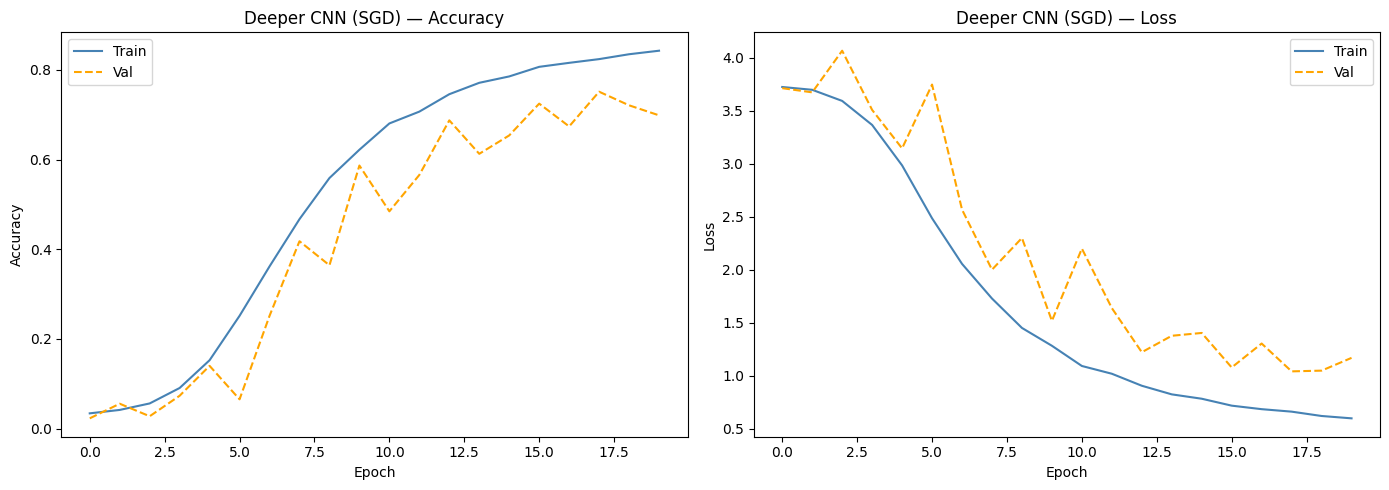

67/67 ━━━━━━━━━━━━━━━━━━━━ 12s 177ms/step

  Deeper CNN (SGD)
  Accuracy : 0.7514  (75.14%)

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.80      0.70      0.75        57
     Class 1       0.78      0.81      0.79        57
     Class 2       0.92      0.83      0.87        58
     Class 3       0.85      0.73      0.78        55
     Class 4       0.90      0.60      0.72        47
     Class 5       0.89      0.82      0.85        57
     Class 6       0.83      0.80      0.82        56
     Class 7       0.92      0.82      0.87        56
     Class 8       0.89      0.71      0.79        58
     Class 9       0.91      0.75      0.83        57
    Class 10       0.75      0.86      0.80        58
    Class 11       0.75      0.75      0.75        56
    Class 12       0.81      0.84      0.82        55
    Class 13       0.70      0.85      0.77        55
    Class 14       0.93      0.78      0.85        54
    Class 15       

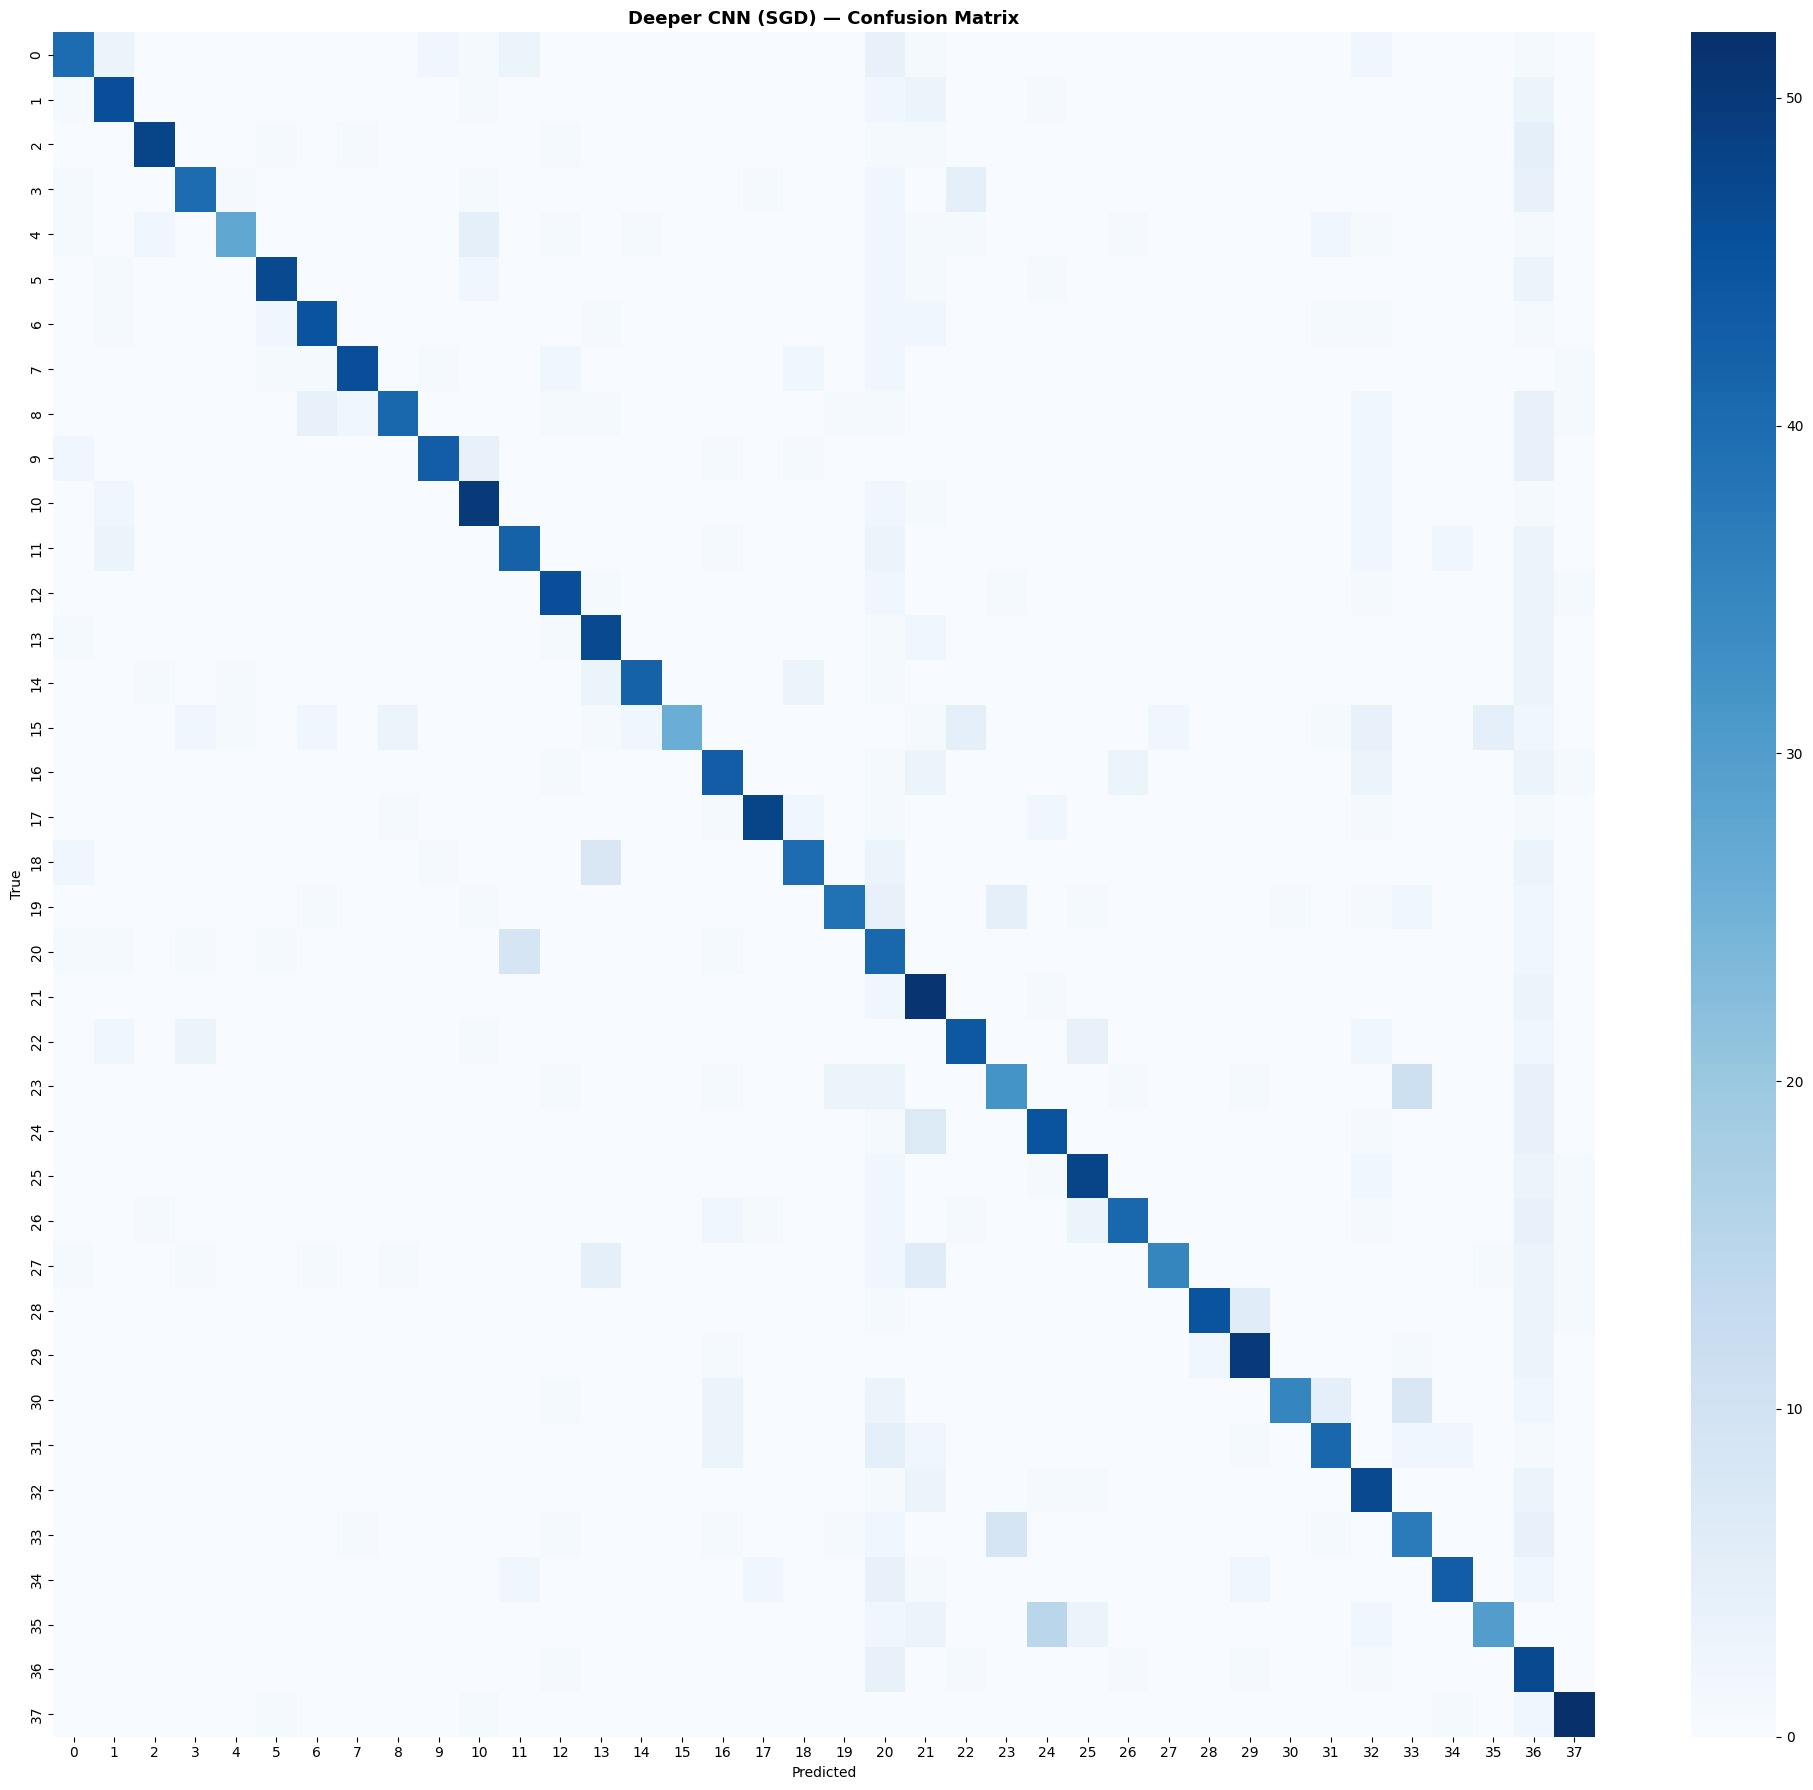

In [34]:
plot_history(history_deeper_sgd, "Deeper CNN (SGD)")
acc_deeper_sgd, _, _ = evaluate_model(deeper_model_sgd, val_gen, "Deeper CNN (SGD)")

### Ablation Study: Remove Dropout

Training Ablation model (Deeper, NO Dropout) ...
Epoch 1/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 240s 850ms/step - accuracy: 0.0399 - loss: 3.6862 - val_accuracy: 0.0261 - val_loss: 4.4364
Epoch 2/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 224s 827ms/step - accuracy: 0.0919 - loss: 3.2998 - val_accuracy: 0.0681 - val_loss: 3.9555
Epoch 3/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 224s 825ms/step - accuracy: 0.2055 - loss: 2.7115 - val_accuracy: 0.1264 - val_loss: 4.0039
Epoch 4/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 223s 824ms/step - accuracy: 0.4129 - loss: 1.9221 - val_accuracy: 0.4310 - val_loss: 1.9393
Epoch 5/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 223s 824ms/step - accuracy: 0.6108 - loss: 1.2859 - val_accuracy: 0.4174 - val_loss: 2.0332
Epoch 6/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 222s 820ms/step - accuracy: 0.7086 - loss: 1.0026 - val_accuracy: 0.6287 - val_loss: 1.3812
Epoch 7/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 223s 822ms/step - accuracy: 0.7577 - loss: 0.8461 - val_accuracy: 0.6418 - val_loss: 1.2582
Epoch 8/20
271/271 ━━━━━━━━

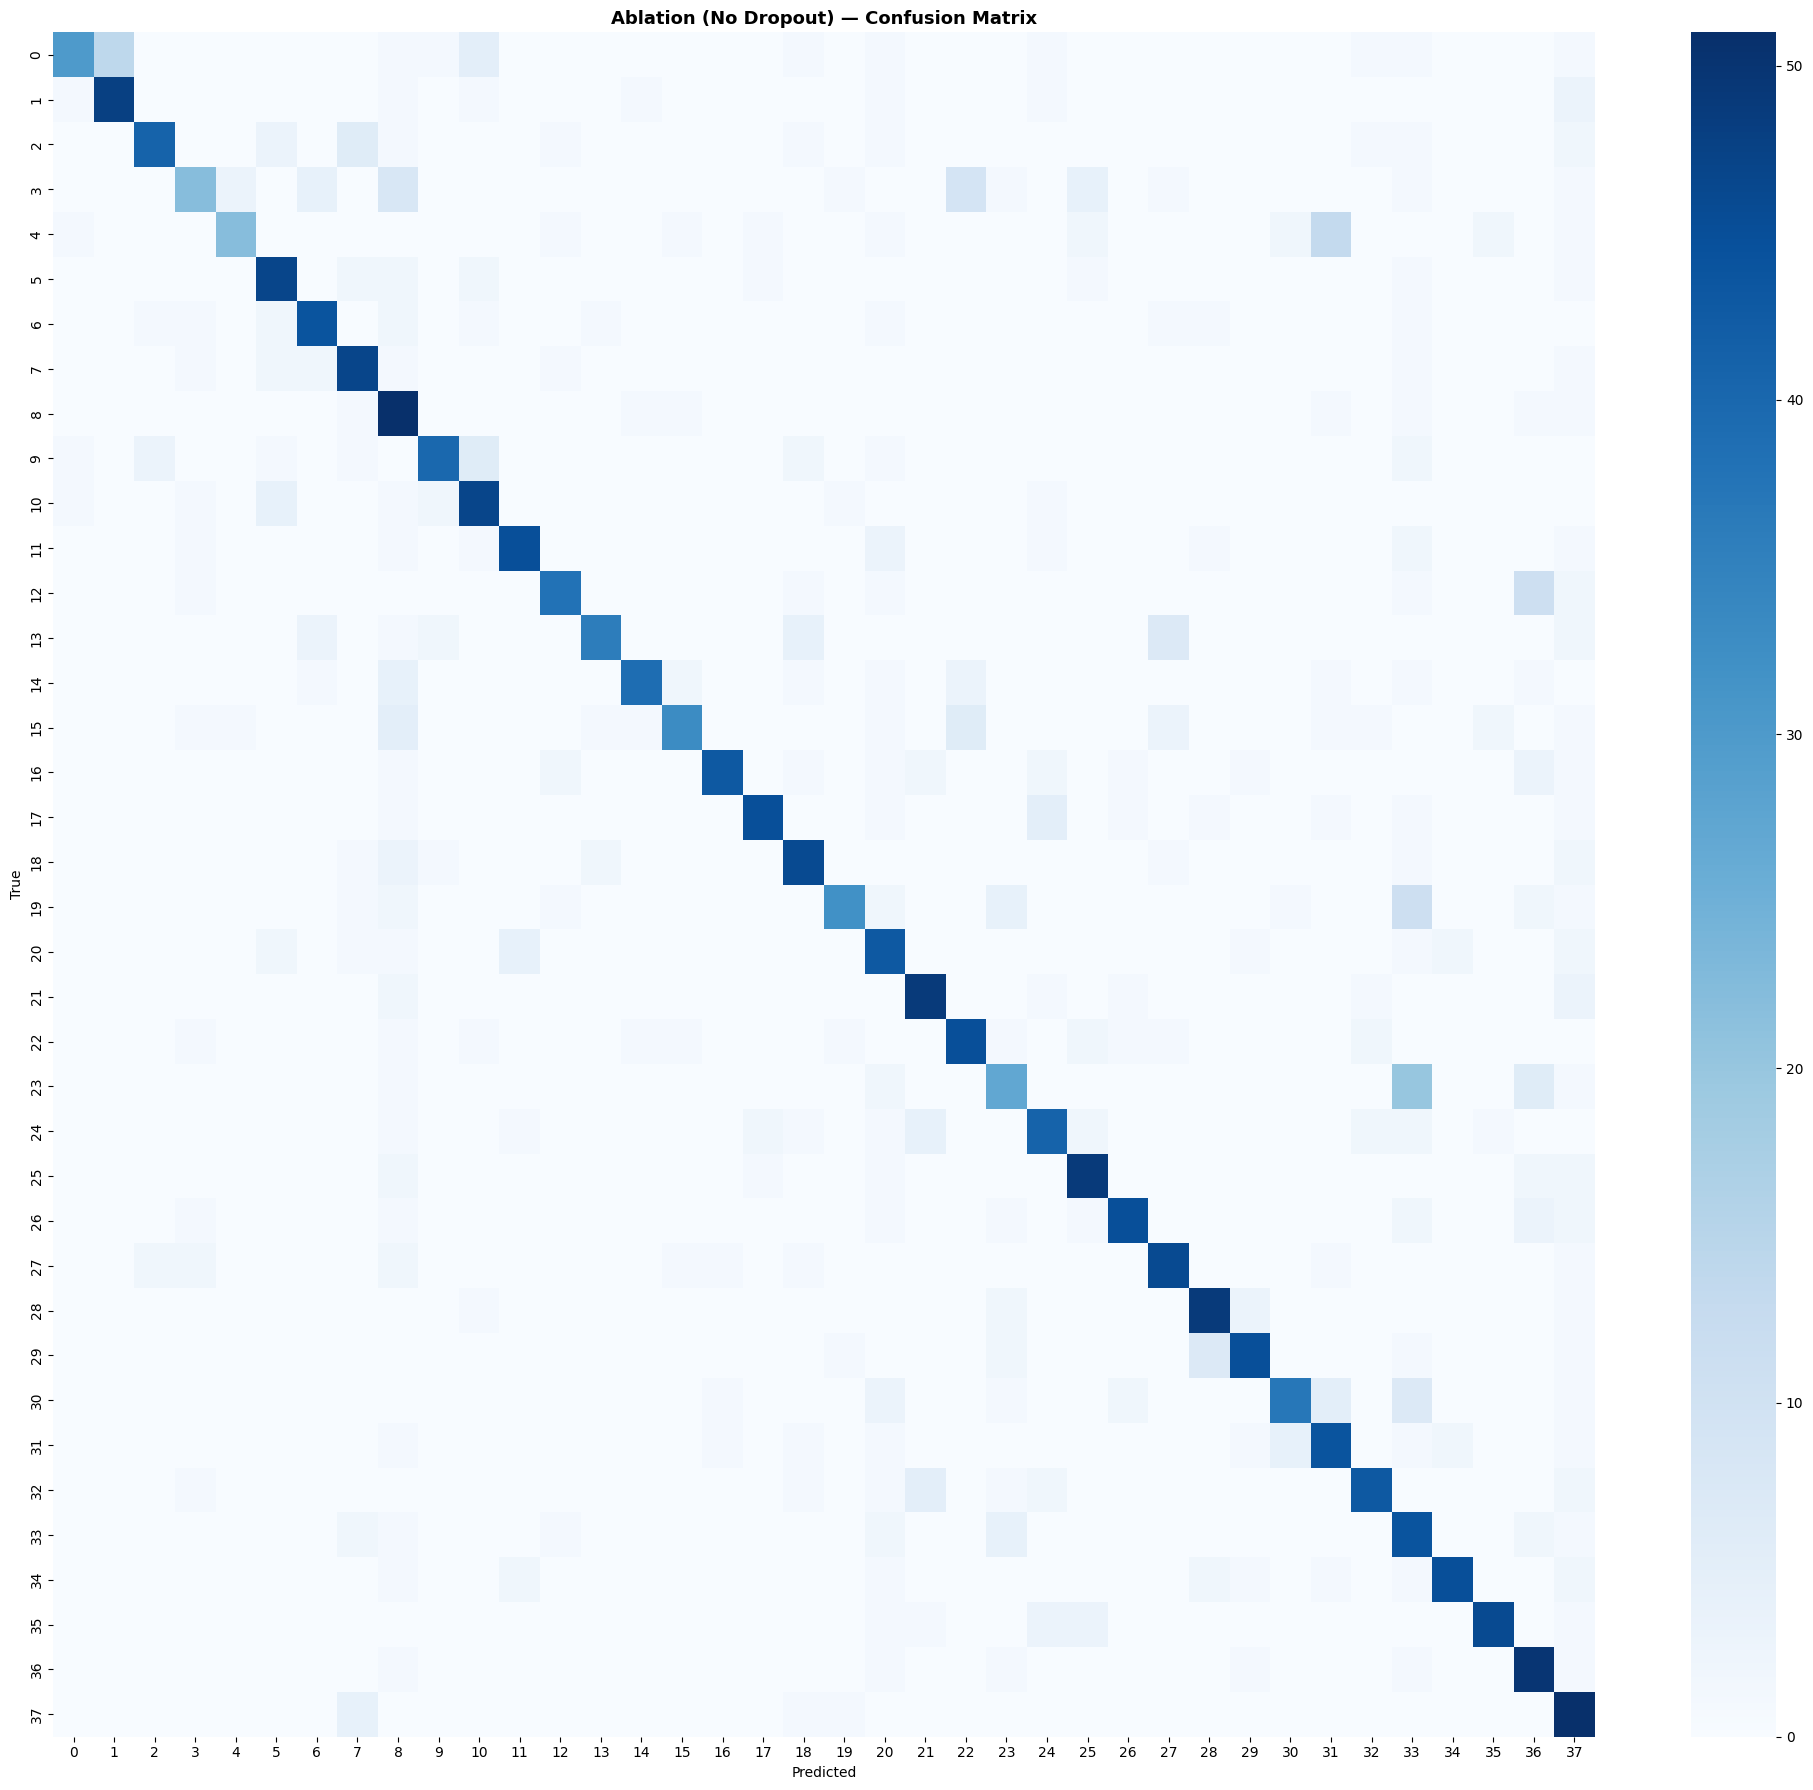

In [35]:
ablation_model = build_deeper_model(include_dropout=False)
ablation_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

print("Training Ablation model (Deeper, NO Dropout) ...")
history_ablation = ablation_model.fit(
    train_gen,
    epochs          = 20,
    validation_data = val_gen,
    callbacks       = [EarlyStopping(monitor='val_loss', patience=5,
                                     restore_best_weights=True)],
    verbose = 1
)
acc_ablation, _, _ = evaluate_model(ablation_model, val_gen, "Ablation (No Dropout)")

### Comparative Analysis — All Part A Models

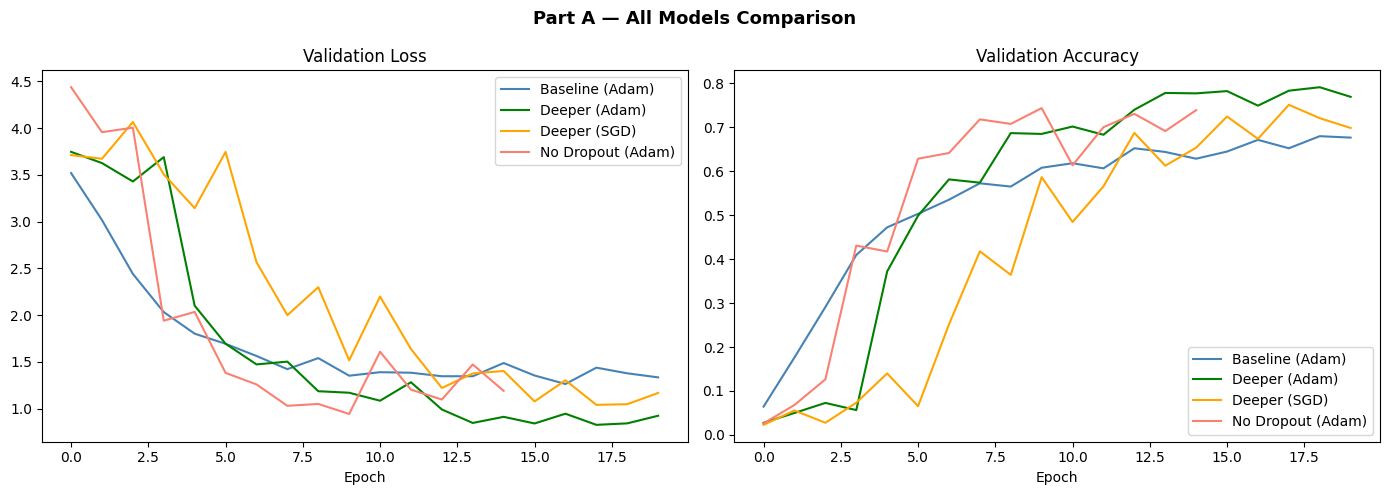

In [36]:
# ── Overlay loss curves ────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for hist, label, color in [
    (history_baseline,    "Baseline (Adam)",   "steelblue"),
    (history_deeper_adam, "Deeper (Adam)",      "green"),
    (history_deeper_sgd,  "Deeper (SGD)",       "orange"),
    (history_ablation,    "No Dropout (Adam)",  "salmon"),
]:
    ax1.plot(hist.history['val_loss'],     label=label, color=color)
    ax2.plot(hist.history['val_accuracy'], label=label, color=color)

ax1.set_title("Validation Loss");     ax1.set_xlabel("Epoch"); ax1.legend()
ax2.set_title("Validation Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()
plt.suptitle("Part A — All Models Comparison", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("partA_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

In [37]:
# ── Summary table ──────────────────────────────────────────────────────────────
partA_results = {
    "Baseline CNN (Adam)"    : (acc_baseline,    time_baseline),
    "Deeper CNN (Adam)"      : (acc_deeper_adam, time_deeper_adam),
    "Deeper CNN (SGD)"       : (acc_deeper_sgd,  time_deeper_sgd),
    "Ablation (No Dropout)" : (acc_ablation,    None),
}

print(f"\n{'Model':<28} {'Accuracy':>10} {'Train Time':>12}")
print("-" * 54)
for name, (acc, t) in partA_results.items():
    t_str = f"{t/60:.1f} min" if t else "N/A"
    print(f"{name:<28} {acc*100:>9.2f}% {t_str:>12}")


Model                          Accuracy   Train Time
------------------------------------------------------
Baseline CNN (Adam)              67.16%     27.2 min
Deeper CNN (Adam)                78.36%     75.0 min
Deeper CNN (SGD)                 75.14%     77.3 min
Ablation (No Dropout)            74.39%          N/A


---
## Part B — Transfer Learning with MobileNetV2

**Why MobileNetV2?**
- Pre-trained on ImageNet → powerful low-level feature representations
- Native input size = **224×224** — matches our dataset exactly (zero resize cost)
- Lightweight inverted residuals → fast training even on CPU/Colab

**Strategy:**
1. **Phase 1 — Feature Extraction:** freeze entire base, train only new classification head
2. **Phase 2 — Fine-tuning:** unfreeze top 50 layers, train with very low LR (1e-5) to avoid catastrophic forgetting

In [38]:
# ── MobileNetV2 needs pixels in [-1, 1] instead of [0, 1] ─────────────────────
def mobilenet_preprocess_aug(img):
    """Gaussian blur augmentation + MobileNetV2 scaling."""
    img = gaussian_blur_fn(img)
    return mobilenet_preprocess(img)


tl_train_datagen = ImageDataGenerator(
    preprocessing_function = mobilenet_preprocess_aug,
    zoom_range             = 0.15,
    validation_split       = VAL_SPLIT
)
tl_eval_datagen = ImageDataGenerator(
    preprocessing_function = mobilenet_preprocess,
    validation_split       = VAL_SPLIT
)

tl_train_gen = tl_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=SORTED_CLASSES,
    subset='training', shuffle=True, seed=SEED
)
tl_val_gen = tl_eval_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=SORTED_CLASSES,
    subset='validation', shuffle=False, seed=SEED
)

print("Transfer learning generators ready.")

Found 8648 images belonging to 38 classes.
Found 2144 images belonging to 38 classes.
Transfer learning generators ready.


In [39]:
# ── Build the transfer learning model ─────────────────────────────────────────
base_model = MobileNetV2(
    weights     = 'imagenet',
    include_top = False,
    input_shape = (224, 224, 3)
)
base_model.trainable = False   # Phase 1: freeze everything

inputs  = keras.Input(shape=(224, 224, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(256, activation='relu',
                        kernel_regularizer=regularizers.l2(1e-4))(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(128, activation='relu',
                        kernel_regularizer=regularizers.l2(1e-4))(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

tl_model = keras.Model(inputs, outputs, name="MobileNetV2_TL")
tl_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
tl_model.summary()

Model: "MobileNetV2_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,623,718 (10.01 MB)

 Trainable params: 365,734 (1.40 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [40]:
# ── Phase 1: Feature Extraction ────────────────────────────────────────────────
print("Phase 1 — Feature Extraction (base frozen) ...")
t0_tl = time.time()

# MobileNetV2 model input is 224x224, so generators must match this size
TL_IMG_SIZE = (224, 224)

tl_train_gen = tl_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=TL_IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=SORTED_CLASSES,
    subset='training', shuffle=True, seed=SEED
)
tl_val_gen = tl_eval_datagen.flow_from_directory(
    TRAIN_DIR, target_size=TL_IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=SORTED_CLASSES,
    subset='validation', shuffle=False, seed=SEED
)

# Important for re-running cells out of order:
# reset to frozen base + fresh compile before Phase 1 fit
base_model.trainable = False
for layer in base_model.layers:
    layer.trainable = False

tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_tl_p1 = tl_model.fit(
    tl_train_gen,
    epochs          = 15,
    validation_data = tl_val_gen,
    callbacks       = [
        EarlyStopping(monitor='val_loss', patience=5,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=1e-8, verbose=1)
    ],
    verbose = 1
)
print("Phase 1 complete.")

Phase 1 — Feature Extraction (base frozen) ...
Found 8648 images belonging to 38 classes.
Found 2144 images belonging to 38 classes.
Epoch 1/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 215s 768ms/step - accuracy: 0.1715 - loss: 2.9593 - val_accuracy: 0.4366 - val_loss: 1.9499 - learning_rate: 0.0010
Epoch 2/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 206s 761ms/step - accuracy: 0.4001 - loss: 1.9189 - val_accuracy: 0.5886 - val_loss: 1.4138 - learning_rate: 0.0010
Epoch 3/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 205s 757ms/step - accuracy: 0.5024 - loss: 1.5691 - val_accuracy: 0.6059 - val_loss: 1.2835 - learning_rate: 0.0010
Epoch 4/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 206s 759ms/step - accuracy: 0.5672 - loss: 1.3686 - val_accuracy: 0.6395 - val_loss: 1.1587 - learning_rate: 0.0010
Epoch 5/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 207s 762ms/step - accuracy: 0.5890 - loss: 1.2900 - val_accuracy: 0.6530 - val_loss: 1.1198 - learning_rate: 0.0010
Epoch 6/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 206s 758ms/step - accuracy: 0.6162 - loss: 1.20

In [41]:
# ── Phase 2: Fine-Tuning (unfreeze top 50 layers) ─────────────────────────────
print("Phase 2 — Fine-Tuning (top 50 layers unfrozen) ...")

base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

# Recompile with much lower LR to avoid catastrophic forgetting
tl_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-5),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

trainable_count = sum(1 for l in tl_model.trainable_variables)
print(f"Trainable weight tensors : {trainable_count}")

history_tl_p2 = tl_model.fit(
    tl_train_gen,
    epochs          = 15,
    validation_data = tl_val_gen,
    callbacks       = [
        EarlyStopping(monitor='val_loss', patience=7,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                          patience=3, min_lr=1e-9, verbose=1),
        ModelCheckpoint('best_tl.keras', monitor='val_accuracy',
                        save_best_only=True, verbose=0)
    ],
    verbose = 1
)

time_tl = time.time() - t0_tl
print(f"\nTotal TL training time : {time_tl/60:.1f} min")

Phase 2 — Fine-Tuning (top 50 layers unfrozen) ...
Trainable weight tensors : 57
Epoch 1/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 279s 970ms/step - accuracy: 0.5182 - loss: 1.6120 - val_accuracy: 0.7188 - val_loss: 0.9445 - learning_rate: 1.0000e-05
Epoch 2/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 262s 967ms/step - accuracy: 0.6347 - loss: 1.1710 - val_accuracy: 0.7491 - val_loss: 0.8586 - learning_rate: 1.0000e-05
Epoch 3/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 262s 965ms/step - accuracy: 0.6874 - loss: 0.9996 - val_accuracy: 0.7729 - val_loss: 0.7757 - learning_rate: 1.0000e-05
Epoch 4/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 261s 964ms/step - accuracy: 0.7170 - loss: 0.9009 - val_accuracy: 0.7878 - val_loss: 0.7280 - learning_rate: 1.0000e-05
Epoch 5/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 261s 963ms/step - accuracy: 0.7421 - loss: 0.8162 - val_accuracy: 0.8018 - val_loss: 0.6787 - learning_rate: 1.0000e-05
Epoch 6/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 262s 968ms/step - accuracy: 0.7549 - loss: 0.7915 - val_accuracy: 0.8190 - val_

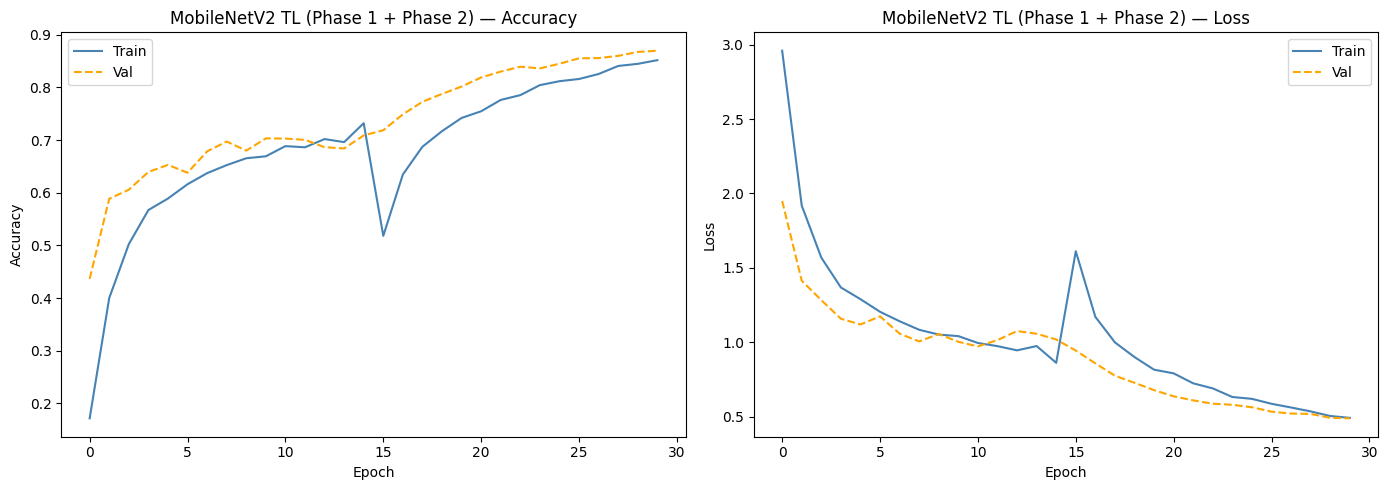

In [42]:
# ── Plot combined Phase 1 + Phase 2 curves ─────────────────────────────────────
def merge_histories(h1, h2):
    merged = {k: h1.history[k] + h2.history[k] for k in h1.history}
    class _H:
        history = merged
    return _H()

plot_history(merge_histories(history_tl_p1, history_tl_p2),
             "MobileNetV2 TL (Phase 1 + Phase 2)")

67/67 ━━━━━━━━━━━━━━━━━━━━ 33s 466ms/step

  MobileNetV2 Transfer Learning
  Accuracy : 0.8699  (86.99%)

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.90      0.77      0.83        57
     Class 1       0.92      0.98      0.95        57
     Class 2       0.98      0.90      0.94        58
     Class 3       0.91      0.75      0.82        55
     Class 4       0.94      0.66      0.78        47
     Class 5       0.86      0.96      0.91        57
     Class 6       0.81      0.93      0.87        56
     Class 7       0.91      0.93      0.92        56
     Class 8       0.91      0.91      0.91        58
     Class 9       0.83      0.88      0.85        57
    Class 10       0.89      0.88      0.89        58
    Class 11       0.96      0.93      0.95        56
    Class 12       0.89      0.87      0.88        55
    Class 13       0.81      0.91      0.85        55
    Class 14       0.89      0.74      0.81        54
    Cl

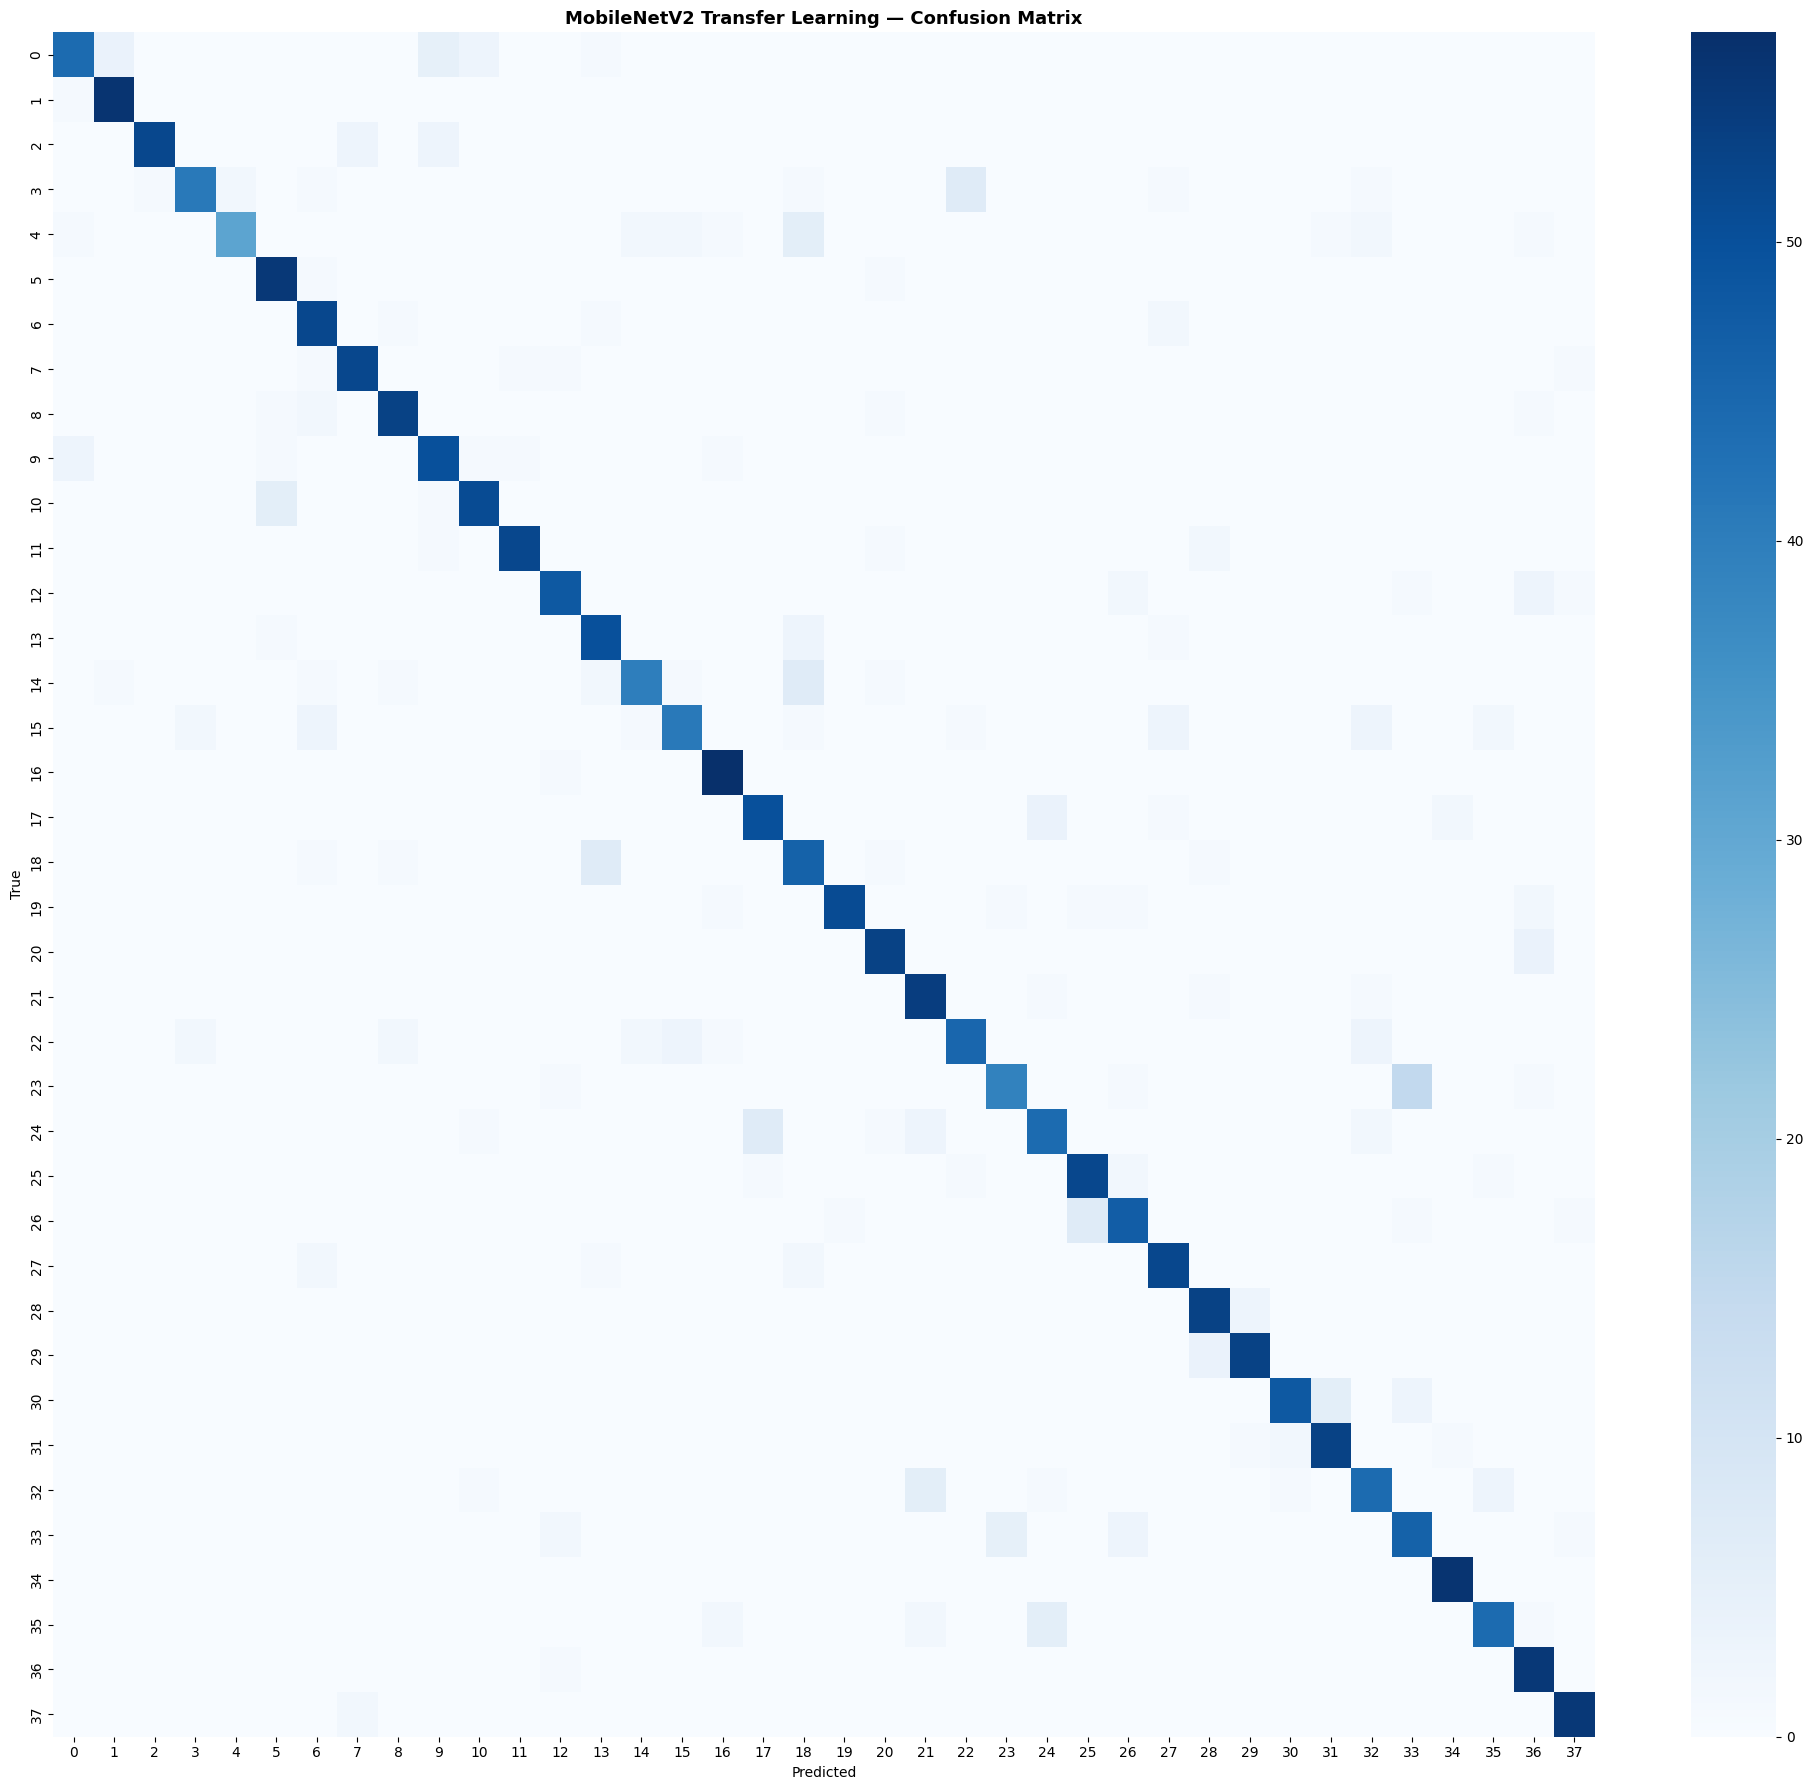

In [43]:
acc_tl, _, _ = evaluate_model(tl_model, tl_val_gen, "MobileNetV2 Transfer Learning")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8509804..0.7490196].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9607843..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.54509807].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.75686276..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.7647059].
Clipping input data to the vali

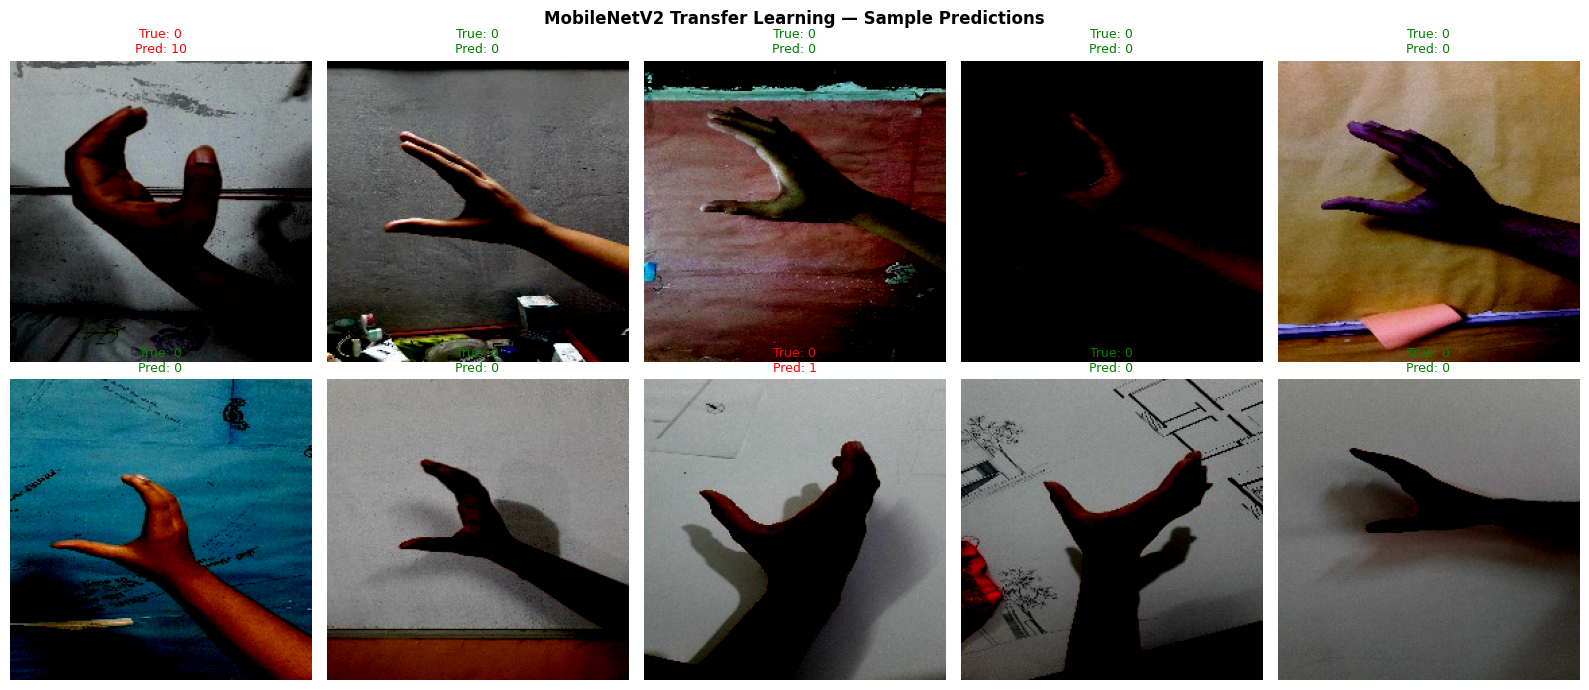

In [44]:
visualize_predictions(tl_model, tl_val_gen, title="MobileNetV2 Transfer Learning")

## Test Set Inference (Unlabelled Test Images)

Since the Test folder contains raw JPGs with no class subfolders, we run direct inference on them.
No accuracy metrics are possible here — only predictions.

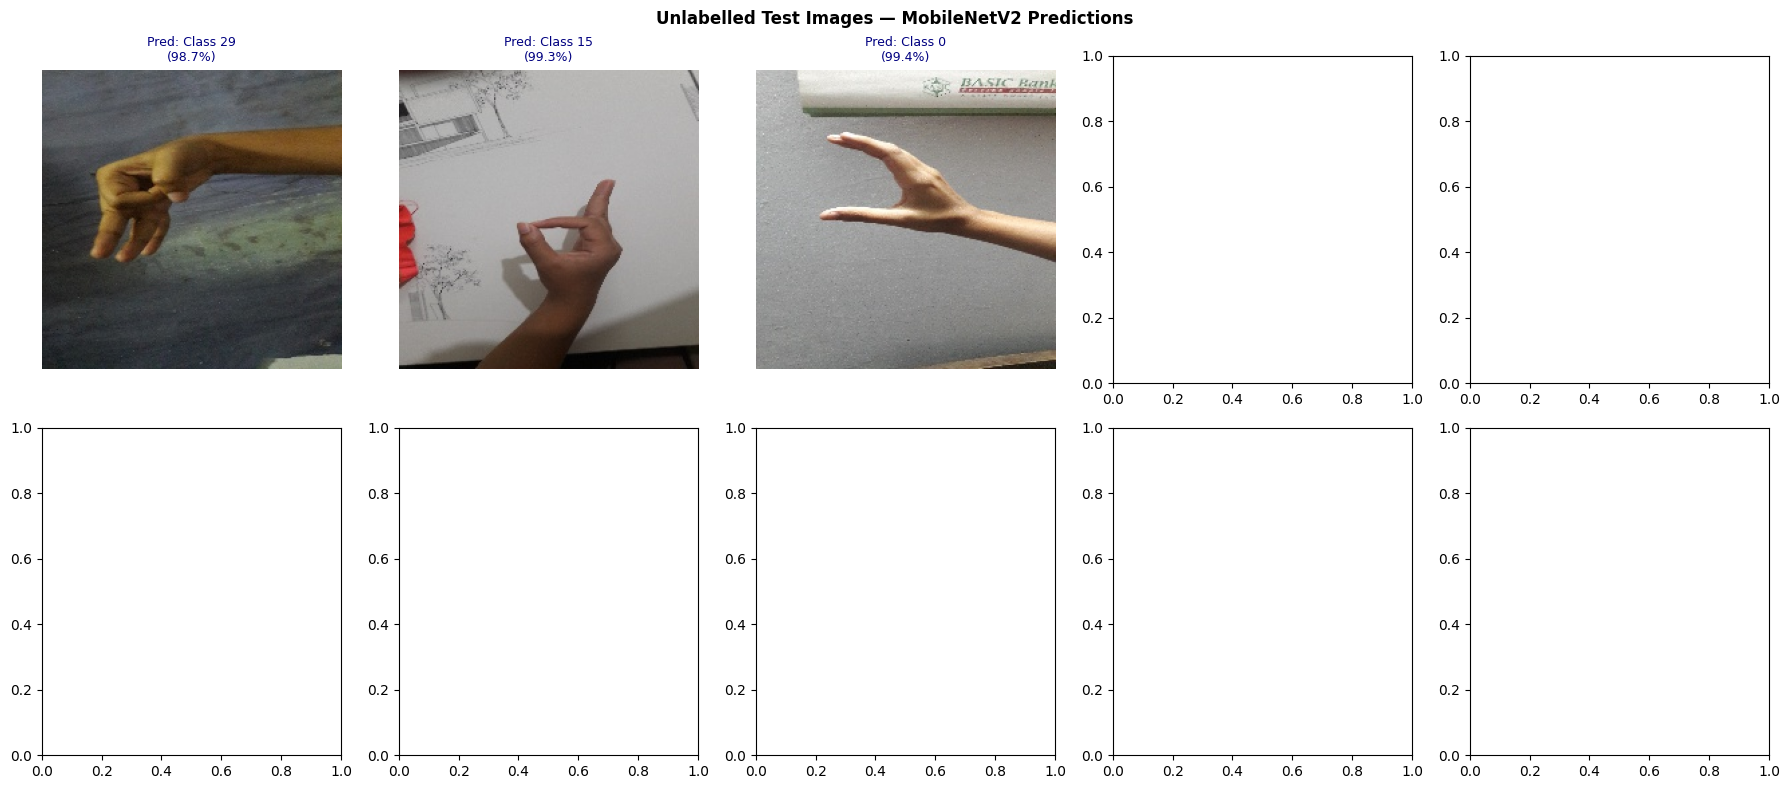

In [45]:
from tensorflow.keras.preprocessing import image as keras_image

def predict_single_image(model, img_path, preprocess_fn=None):
    """Load a single image, predict its class."""
    img  = keras_image.load_img(img_path, target_size=IMG_SIZE)
    arr  = keras_image.img_to_array(img)
    if preprocess_fn:
        arr = preprocess_fn(arr)
    else:
        arr = arr / 255.0
    arr  = np.expand_dims(arr, axis=0)
    pred = model.predict(arr, verbose=0)[0]
    cls  = SORTED_CLASSES[np.argmax(pred)]
    conf = np.max(pred)
    return cls, conf


# ── Show predictions for the first 10 test images ─────────────────────────────
test_images = sorted(
    list(TEST_DIR.glob("*.jpg")) + list(TEST_DIR.glob("*.png"))
)[:10]

if test_images:
    fig, axes = plt.subplots(2, 5, figsize=(18, 8))
    axes = axes.flatten()
    for i, img_path in enumerate(test_images):
        cls, conf = predict_single_image(tl_model, img_path,
                                          preprocess_fn=mobilenet_preprocess)
        img = mpimg.imread(str(img_path))
        axes[i].imshow(img)
        axes[i].set_title(f"Pred: Class {cls}\n({conf*100:.1f}%)",
                          fontsize=9, color='navy')
        axes[i].axis('off')
    plt.suptitle("Unlabelled Test Images — MobileNetV2 Predictions",
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig("test_predictions.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No test images found at:", TEST_DIR)

## Final Summary — All Models

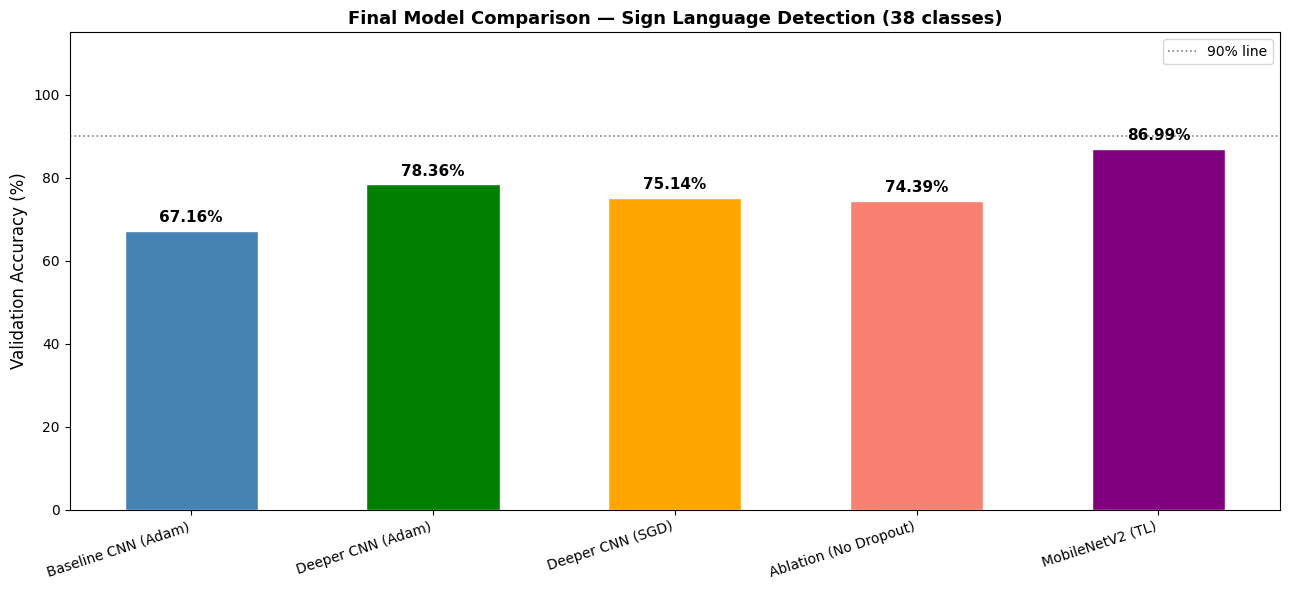


FINAL ACCURACY SUMMARY
  Baseline CNN (Adam)          : 67.16%
  Deeper CNN (Adam)            : 78.36%
  Deeper CNN (SGD)             : 75.14%
  Ablation (No Dropout)        : 74.39%
  MobileNetV2 (TL)             : 86.99%


In [46]:
all_results = {
    "Baseline CNN (Adam)"    : acc_baseline,
    "Deeper CNN (Adam)"      : acc_deeper_adam,
    "Deeper CNN (SGD)"       : acc_deeper_sgd,
    "Ablation (No Dropout)" : acc_ablation,
    "MobileNetV2 (TL)"       : acc_tl,
}

names  = list(all_results.keys())
values = [v * 100 for v in all_results.values()]
colors = ['steelblue', 'green', 'orange', 'salmon', 'purple']

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(names, values, color=colors, edgecolor='white', width=0.55)
ax.bar_label(bars, fmt='%.2f%%', padding=4, fontsize=11, fontweight='bold')
ax.set_ylim(0, 115)
ax.set_ylabel("Validation Accuracy (%)", fontsize=12)
ax.set_title("Final Model Comparison — Sign Language Detection (38 classes)",
             fontsize=13, fontweight='bold')
ax.set_xticklabels(names, rotation=18, ha='right', fontsize=10)
ax.axhline(90, color='gray', linestyle=':', linewidth=1.2, label='90% line')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("final_summary.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*55)
print("FINAL ACCURACY SUMMARY")
print("="*55)
for name, acc in all_results.items():
    print(f"  {name:<28} : {acc*100:.2f}%")
print("="*55)

In [47]:
# ── Save all models ────────────────────────────────────────────────────────────
baseline_model.save("model_baseline.keras")
deeper_model.save("model_deeper_adam.keras")
tl_model.save("model_mobilenetv2_tl.keras")

print("Models saved:")
for f in ["model_baseline.keras", "model_deeper_adam.keras", "model_mobilenetv2_tl.keras"]:
    print(f"  ✓ {f}")

Models saved:
  ✓ model_baseline.keras
  ✓ model_deeper_adam.keras
  ✓ model_mobilenetv2_tl.keras
